# Load data

## Import necessary libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import scienceplots
# import seaborn as sns
import numpy as np
import json
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## Set global variables

In [5]:
# Set style for better plots
# plt.style.use('seaborn-v0_8-paper')
# sns.set_palette("muted")

# Set style for paper-like plots
# plt.style.use(['science','ieee','no-latex'])
# plt.style.use(['science','no-latex'])
plt.style.use(['science'])

# Global configuration for plot duration limit
# This is the maximum duration for which we will plot individual requests
# Necessary because malicious requests require longer to be interrupted in the tests
PLOT_DURATION_LIMIT = 60

## Data Loader

In [6]:
DATA_CONFIGS = {
    'stresstest': {
        'data_patterns': [
            "fairness_test_data_regular_*.csv",
            "fairness_test_data_malicious_*.csv"
        ],
        'metadata_patterns': [
            "fairness_test_metadata_*.json"
        ],
    },
    'baseline': {
        'data_patterns': [
            "fairness_baseline_tenant1_*.csv",
            "fairness_baseline_tenant2_*.csv"
        ],
        'metadata_patterns': [
            "fairness_baseline_metadata_*.json"
        ]
    }
}

def load_latest_stresstest_data(src_dir="./"):
    """Load the most recent test data"""
    return _load_data_generic(src_dir,  DATA_CONFIGS['stresstest'])

def load_latest_baseline_data(src_dir="./"):
    """Load baseline test data"""
    return _load_data_generic(src_dir,  DATA_CONFIGS['baseline'])


def _load_data_generic(src_dir, config):
    """
    Generic data loading function
    
    Args:
        src_dir: Source directory
        config: Dictionary with loading configuration:
            - data_patterns: List of patterns to load data files
            - metadata_patterns: List of patterns to load metadata
    """
    # Find files matching search patterns
    all_files = _find_files_by_pattern(src_dir, config['data_patterns'])
    
    if not all_files:
        raise FileNotFoundError(f"No data files found matching patterns: {config['search_patterns']}")
    
    # Get the latest experiment
    latest_file = max(all_files)
    timestamp = _get_timestamp_from_file(latest_file)
    
    # Load data files
    dfs = _load_data_from_file(src_dir, timestamp, config['data_patterns'])
    
    if not dfs:
        raise FileNotFoundError(f"No data files found for experiment {timestamp}")
    
    # Combine dataframes
    df = pd.concat(dfs, ignore_index=True)

    # Load metadata
    metadata = _load_data_from_file(src_dir, timestamp, config['metadata_patterns'],format='json')
    if not metadata:
        raise FileNotFoundError(f"No metadata files found for timestamp {timestamp}")
    
    return df, metadata[0], timestamp

def _find_files_by_pattern(src_dir, patterns):
    """Find files matching any of the given patterns"""
    all_files = []
    for pattern in patterns:
        files = glob.glob(f"{src_dir}/{pattern}")
        if not files:
            raise FileNotFoundError(f"No files found matching pattern: {pattern}")
        all_files.extend(files)
    return all_files

def _get_timestamp_from_file(filepath):
    """Extract timestamp from filename"""
    return filepath.split('_')[-1].split('.')[0]

def _load_data_from_file(src_dir, timestamp, patterns, format='csv'):
    """Load data files, trying multiple patterns"""
    results = []
    for pattern in patterns:
        file_pattern = pattern.replace('*', timestamp)
        file_path = f"{src_dir}/{file_pattern}"
        if glob.glob(file_path):
            if format == 'csv':
                results.append(pd.read_csv(file_path))
            elif format == 'json':
                with open(file_path, 'r') as f:
                    results.append(json.load(f))
        else:
            print(f"File not found: {file_path}")
    return results



In [7]:
def load_all_stresstest_data(src_dir="./"):
    """Load all available stress test data"""
    return _load_all_data_generic(src_dir, DATA_CONFIGS['stresstest'])

def load_all_baseline_data(src_dir="./"):
    """Load all available baseline test data"""
    return _load_all_data_generic(src_dir, DATA_CONFIGS['baseline'])

def _load_all_data_generic(src_dir, config):
    """
    Generic function to load all available test data
    
    Args:
        src_dir: Source directory
        config: Dictionary with loading configuration
        
    Returns:
        list of tuples: [(df, metadata, timestamp), ...]
    """
    # Find all files matching search patterns
    all_files = _find_files_by_pattern(src_dir, config['data_patterns'])
    
    if not all_files:
        raise FileNotFoundError(f"No data files found matching patterns: {config['data_patterns']}")
    
    # Extract all unique timestamps
    timestamps = set()
    for file_path in all_files:
        timestamp = _get_timestamp_from_file(file_path)
        timestamps.add(timestamp)
    
    # Load data for each timestamp
    all_experiments = []
    for timestamp in sorted(timestamps):
        try:
            # Load data files for this timestamp
            dfs = _load_data_from_file(src_dir, timestamp, config['data_patterns'])
            
            if not dfs:
                print(f"Warning: No data files found for timestamp {timestamp}")
                continue
            
            # Combine dataframes
            df = pd.concat(dfs, ignore_index=True)

            # Load metadata for this timestamp
            metadata = _load_data_from_file(src_dir, timestamp, config['metadata_patterns'], format='json')
            if not metadata:
                print(f"Warning: No metadata files found for timestamp {timestamp}")
                continue
            
            all_experiments.append((df, metadata[0], timestamp))
            
        except Exception as e:
            print(f"Warning: Error loading data for timestamp {timestamp}: {e}")
            continue
    
    if not all_experiments:
        raise FileNotFoundError("No complete experiments found (data + metadata)")
    
    print(f"Loaded {len(all_experiments)} experiments")
    return all_experiments

def aggregate_multiple_experiments(experiments_data, preprocess_func):
    """
    Aggregate metrics across multiple experiments
    
    Args:
        experiments_data: List of (df, metadata, timestamp) tuples
        preprocess_func: Function to preprocess individual experiment data
        
    Returns:
        dict: Aggregated statistics by role
    """
    merged_data = []
    
    # Data is aggregated as one dataframe
    # Metadata is processed on the final aggregated dataframe
    for df, metadata, timestamp in experiments_data:
        # Preprocess the data
        preprocessed_df = preprocess_func(df, metadata)
        preprocessed_df['experiment_id'] = timestamp
        merged_data.append(preprocessed_df)
    
    # Combine all dataframes into one
    combined_df = pd.concat(merged_data, ignore_index=True)


    return combined_df

## Data Preprocessing

In [8]:
def preprocess_data(df, metadata):
    """Preprocess the individual request data"""
    # Convert start_time to numeric if it's not already
    df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
    
    # Calculate elapsed seconds from the start of the test
    min_time = df['start_time'].min()
    df['elapsed_seconds'] = df['start_time'] - min_time
    
    # Convert duration from milliseconds to seconds for easier analysis
    df['duration_seconds'] = df['duration_ms'] / 1000.0
    
    # Calculate relative increase from baseline for each request
    baseline_latency = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    df['relative_increase_percent'] = ((df['duration_ms'] - baseline_latency) / baseline_latency) * 100
    df['relative_muliplier_factor'] = df['duration_ms'] / baseline_latency
    
    # Add phase identification based on the test type
    df['phase'] = 'stress'
    
    # Sort by time for proper plotting
    df = df.sort_values(['role', 'elapsed_seconds']).reset_index(drop=True)
    
    return df

def preprocess_baseline_data(df, metadata):
    """Preprocess baseline test data"""
    # Convert start_time to numeric if it's not already
    df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
    
    # Calculate elapsed seconds from the start of the baseline test
    min_time = df['start_time'].min()
    df['elapsed_seconds'] = df['start_time'] - min_time
    
    # Convert duration from milliseconds to seconds for easier analysis
    df['duration_seconds'] = df['duration_ms'] / 1000.0
    
    # Add phase identification (all baseline data is 'baseline' phase)
    df['phase'] = 'baseline'
    
    # Sort by time for proper plotting
    df = df.sort_values(['role', 'elapsed_seconds']).reset_index(drop=True)
    
    return df


## Plot utils

In [9]:
def save_plot(fig, filename):
    
    fig.savefig(f'{filename}.png', bbox_inches='tight', dpi=300)
    
    current_backend = matplotlib.get_backend()
    current_usetex = matplotlib.rcParams['text.usetex']
    
    # Switch to PGF for high-quality output
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
    })
    # Save without any axis title
    # Remove titles from all axes before saving
    for ax in fig.get_axes():
        ax.set_title('')  # Remove individual subplot titles
    
    fig.savefig(f'{filename}.pgf', bbox_inches='tight')
    
    # Switch back to interactive backend
    matplotlib.use(current_backend)
    matplotlib.rcParams.update({"text.usetex": current_usetex})


def plot_for_paper(text_width=3.31314,
                aspect_ratio=6/8,
                scale=1.0):
    """Resize the plot to a specific text width and aspect ratio"""
    scale = 1.0
    width = text_width * scale
    height = width * aspect_ratio
    fig, ax =  plt.subplots(figsize=(width, height), dpi=300)
    return fig,ax


## Plot functions

In [10]:

def aggregate_data_by_time_window(df, window_size=1.0):
    """Aggregate individual requests into time windows for analysis"""
    aggregated_data = []
    
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
        
        # Create time bins
        max_time = role_data['elapsed_seconds'].max()
        time_bins = np.arange(0, max_time + window_size, window_size)
        
        for i in range(len(time_bins) - 1):
            bin_start = time_bins[i]
            bin_end = time_bins[i + 1]
            
            # Find all requests within this time bin
            bin_mask = (role_data['elapsed_seconds'] >= bin_start) & (role_data['elapsed_seconds'] < bin_end)
            bin_data = role_data[bin_mask]
            
            if len(bin_data) > 0:
                # Calculate aggregated metrics for this window
                avg_latency = bin_data['duration_ms'].mean()
                std_latency = bin_data['duration_ms'].std()
                error_rate = bin_data['is_error'].mean()
                total_requests = len(bin_data)
                
                aggregated_data.append({
                    'time_window_start': bin_start,
                    'time_window_end': bin_end,
                    'time_window_center': (bin_start + bin_end) / 2,
                    'role': role,
                    'avg_latency_ms': avg_latency,
                    'std_latency_ms': std_latency,
                    'error_rate': error_rate,
                    'total_requests': total_requests,
                    'requests_per_second': total_requests / window_size
                })
    
    return pd.DataFrame(aggregated_data)

def plot_individual_requests_scatter(df, metadata, timestamp, save_plots=True, out_dir="./"):   
    """Plot individual request latencies as scatter plot"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Individual request latencies
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Use different markers for successful vs failed requests
        success_data = role_data[~role_data['is_error']]
        error_data = role_data[role_data['is_error']]
        
        if len(success_data) > 0:
            ax1.scatter(success_data['elapsed_seconds'], success_data['duration_ms'], 
                       label=f'{role} Tenant (Success)', alpha=0.6, s=10)
        
        if len(error_data) > 0:
            ax1.scatter(error_data['elapsed_seconds'], error_data['duration_ms'], 
                       label=f'{role} Tenant (Error)', alpha=0.8, s=15, marker='x')
    
    # Add baseline line
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Request Latency (ms)')
    ax1.set_title('Individual Request Latencies Over Time')
    ax1.set_xlim(0, PLOT_DURATION_LIMIT)
    ax1.legend()
    
    # Plot 2: Moving average with confidence intervals
    window_size = 1.0  # 1-second moving window
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Calculate rolling statistics
        role_data_sorted = role_data.sort_values('elapsed_seconds')
        
        # Create time bins for rolling average
        max_time = role_data_sorted['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)  # Every second
        
        rolling_mean = []
        rolling_std = []
        valid_time_points = []
        
        for t in time_points:
            # Get data within window_size/2 around this time point
            window_mask = (role_data_sorted['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data_sorted['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data_sorted[window_mask]
            
            #if len(window_data) >= 5:  # Only if we have enough data points
            rolling_mean.append(window_data['duration_ms'].mean())
            rolling_std.append(window_data['duration_ms'].std())
            valid_time_points.append(t)
        
        if rolling_mean:
            rolling_mean = np.array(rolling_mean)
            rolling_std = np.array(rolling_std)
            valid_time_points = np.array(valid_time_points)
            
            ax2.plot(valid_time_points, rolling_mean, label=f'{role} Tenant (Moving Avg)', linewidth=2)
            ax2.fill_between(valid_time_points, 
                           rolling_mean - rolling_std, 
                           rolling_mean + rolling_std, 
                           alpha=0.2)
    
    ax2.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Average Latency (ms)')
    ax2.set_ylim(bottom=0)
    ax2.set_title(f'Moving Average Latency ({window_size}s window)')
    ax2.set_xlim(0, PLOT_DURATION_LIMIT)
    ax2.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{out_dir}/individual_requests_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
def plot_relative_increase(df, metadata, timestamp, save_plots=True, out_dir="./"):
    """Plot relative increase in latency compared to baseline as a moving average"""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Calculate rolling average of relative increase
    window_size = 1.0  # 1-second moving window
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        # Sort by elapsed time
        role_data_sorted = role_data.sort_values('elapsed_seconds')
        
        # Create time bins for rolling average
        max_time = role_data_sorted['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)  # Every second
        
        rolling_mean = []
        rolling_std = []
        valid_time_points = []
        
        for t in time_points:
            # Get data within window_size/2 around this time point
            window_mask = (role_data_sorted['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data_sorted['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data_sorted[window_mask]
            
            if len(window_data) >= 3:  # Only if we have enough data points
                rolling_mean.append(window_data['relative_increase_percent'].mean())
                rolling_std.append(window_data['relative_increase_percent'].std())
                valid_time_points.append(t)
        
        if rolling_mean:
            rolling_mean = np.array(rolling_mean)
            rolling_std = np.array(rolling_std)
            valid_time_points = np.array(valid_time_points)
            
            ax.plot(valid_time_points, rolling_mean, label=f'{role} Tenant', linewidth=2)
            ax.fill_between(valid_time_points, 
                           rolling_mean - rolling_std, 
                           rolling_mean + rolling_std, 
                           alpha=0.2)
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Relative Increase (%)')
    ax.set_ylim(bottom=0)
    ax.set_title('Average Relative Latency Increase from a non contended environment (1s window)')
    ax.set_xlim(0, PLOT_DURATION_LIMIT)
    ax.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{out_dir}/relative_increase_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_error_analysis(df, metadata, timestamp, save_plots=True, out_dir="./"):
    """Plot error analysis for individual requests"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Error rate over time (aggregated by windows)
    aggregated_df = aggregate_data_by_time_window(df, window_size=1.0)
    
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax1.plot(role_data['time_window_center'], role_data['error_rate'] * 100, 
                label=f'{role} Tenant', marker='o', markersize=4)
    
    ax1.axhline(y=5,  linestyle='--', alpha=0.7, label='Failure Threshold (5%)')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Error Rate (%)')
    ax1.set_title('Error Rate Over Time (1s windows)')
    ax1.set_xlim(0, PLOT_DURATION_LIMIT)
    ax1.legend()
    
    # 2. Error distribution by operation type
    error_by_operation = df.groupby(['role', 'operation'])['is_error'].agg(['count', 'sum', 'mean']).reset_index()
    error_by_operation['error_rate'] = error_by_operation['mean'] * 100
    
    operations = error_by_operation['operation'].unique()
    x_pos = np.arange(len(operations))
    width = 0.35
    
    for i, role in enumerate(error_by_operation['role'].unique()):
        role_data = error_by_operation[error_by_operation['role'] == role]
        values = [role_data[role_data['operation'] == op]['error_rate'].iloc[0] 
                 if len(role_data[role_data['operation'] == op]) > 0 else 0 
                 for op in operations]
        ax2.bar(x_pos + i * width, values, width, label=f'{role} Tenant')
    
    ax2.set_xlabel('Operation Type')
    ax2.set_ylabel('Error Rate (%)')
    ax2.set_title('Error Rate by Operation Type')
    ax2.set_xticks(x_pos + width / 2)
    ax2.set_xticklabels(operations)
    ax2.legend()
    
    # 3. Latency distribution (box plot)
    latency_data = []
    labels = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) > 0:
            latency_data.append(role_data['duration_ms'].values)
            labels.append(f'{role}\n(n={len(role_data)})')
    
    if latency_data:
        ax3.boxplot(latency_data, labels=labels, showfliers=False)
    ax3.set_ylabel('Latency (ms)')
    ax3.set_title('Latency Distribution by Role')
    
    # 4. Request throughput over time
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax4.plot(role_data['time_window_center'], role_data['requests_per_second'], 
                label=f'{role} Tenant', marker='o', markersize=4)
    
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Requests per Second')
    ax4.set_title('Request Throughput Over Time')
    ax4.set_xlim(0, PLOT_DURATION_LIMIT)
    ax4.legend()
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'{out_dir}/error_analysis_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_summary_dashboard(df, metadata, timestamp, save_plots=True, out_dir="./"):
    """Create a comprehensive dashboard for individual request data"""
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    # 1. Moving average latency (top row, full width)
    ax1 = fig.add_subplot(gs[0, :])
    window_size = 1.0
    for role in df['role'].unique():
        role_data = df[df['role'] == role].sort_values('elapsed_seconds')
        if len(role_data) == 0:
            continue
        
        # Calculate rolling average
        max_time = role_data['elapsed_seconds'].max()
        time_points = np.arange(0, max_time, 1.0)
        rolling_mean = []
        valid_time_points = []
        
        for t in time_points:
            window_mask = (role_data['elapsed_seconds'] >= t - window_size/2) & \
                         (role_data['elapsed_seconds'] <= t + window_size/2)
            window_data = role_data[window_mask]
            
            if len(window_data) >= 3:
                rolling_mean.append(window_data['duration_ms'].mean())
                valid_time_points.append(t)
        
        if rolling_mean:
            ax1.plot(valid_time_points, rolling_mean, label=f'{role} Tenant', linewidth=2)
    
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline,  linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    ax1.set_title('Average Request Latency Over Time')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_xlim(0, PLOT_DURATION_LIMIT)
    ax1.legend()
    
    # 2. Error rates (second row, left)
    ax2 = fig.add_subplot(gs[1, 0])
    aggregated_df = aggregate_data_by_time_window(df, window_size=1.0)
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax2.plot(role_data['time_window_center'], role_data['error_rate'] * 100, 
                label=f'{role}', marker='o', markersize=3)
    ax2.axhline(y=5,  linestyle='--', alpha=0.7, label='Threshold')
    ax2.set_title('Error Rate Over Time')
    ax2.set_ylabel('Error Rate (%)')
    ax2.legend()
    
    # 3. Latency distribution (second row, middle)
    ax3 = fig.add_subplot(gs[1, 1])
    latency_data = []
    labels = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) > 0:
            latency_data.append(role_data['duration_ms'].values)
            labels.append(role)
    
    if latency_data:
        ax3.boxplot(latency_data, labels=labels, showfliers=False)
    ax3.set_title('Latency Distribution')
    ax3.set_ylabel('Latency (ms)')
    
    # 4. Request throughput (second row, right)
    ax4 = fig.add_subplot(gs[1, 2])
    for role in aggregated_df['role'].unique():
        role_data = aggregated_df[aggregated_df['role'] == role]
        if len(role_data) == 0:
            continue
        ax4.plot(role_data['time_window_center'], role_data['requests_per_second'], 
                label=f'{role}', marker='o', markersize=3)
    ax4.set_title('Throughput Over Time')
    ax4.set_ylabel('Requests/sec')
    ax4.set_xlim(0, PLOT_DURATION_LIMIT)
    ax4.legend()
    
    # 5. Operation type analysis (third row, left and middle)
    ax5 = fig.add_subplot(gs[2, :2])
    operation_stats = df.groupby(['role', 'operation']).agg({
        'duration_ms': ['count', 'mean', 'std'],
        'is_error': 'mean'
    }).round(2)
    
    # Flatten column names
    operation_stats.columns = ['_'.join(col).strip() for col in operation_stats.columns]
    operation_stats = operation_stats.reset_index()
    
    # Create a grouped bar chart for average latency by operation
    operations = operation_stats['operation'].unique()
    x_pos = np.arange(len(operations))
    width = 0.35
    
    for i, role in enumerate(operation_stats['role'].unique()):
        role_data = operation_stats[operation_stats['role'] == role]
        values = [role_data[role_data['operation'] == op]['duration_ms_mean'].iloc[0] 
                 if len(role_data[role_data['operation'] == op]) > 0 else 0 
                 for op in operations]
        ax5.bar(x_pos + i * width, values, width, label=f'{role} Tenant')
    
    ax5.set_title('Average Latency by Operation Type')
    ax5.set_ylabel('Average Latency (ms)')
    ax5.set_xticks(x_pos + width / 2)
    ax5.set_xticklabels(operations)
    ax5.legend()
    
    # 6. Resource type analysis (third row, right)
    ax6 = fig.add_subplot(gs[2, 2])
    resource_stats = df.groupby(['role', 'resource']).agg({
        'duration_ms': 'mean',
        'is_error': 'mean'
    }).reset_index()
    
    resources = resource_stats['resource'].unique()
    x_pos = np.arange(len(resources))
    
    for i, role in enumerate(resource_stats['role'].unique()):
        role_data = resource_stats[resource_stats['role'] == role]
        values = [role_data[role_data['resource'] == res]['duration_ms'].iloc[0] 
                 if len(role_data[role_data['resource'] == res]) > 0 else 0 
                 for res in resources]
        ax6.bar(x_pos + i * width, values, width, label=f'{role}')
    
    ax6.set_title('Avg Latency by Resource')
    ax6.set_ylabel('Latency (ms)')
    ax6.set_xticks(x_pos + width / 2)
    ax6.set_xticklabels(resources)
    ax6.legend()
    
    # 7. Summary statistics table (bottom row)
    ax7 = fig.add_subplot(gs[3, :])
    ax7.axis('tight')
    ax7.axis('off')
    
    summary_data = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
            
        avg_latency = role_data['duration_ms'].mean()
        median_latency = role_data['duration_ms'].median()
        p95_latency = role_data['duration_ms'].quantile(0.95)
        std_latency = role_data['duration_ms'].std()
        error_rate = role_data['is_error'].mean()
        total_requests = len(role_data)
        
        summary_data.append([
            role,
            f"{total_requests:,}",
            f"{avg_latency:.1f}ms",
            f"{median_latency:.1f}ms", 
            f"{p95_latency:.1f}ms",
            f"{std_latency:.1f}ms",
            f"{error_rate * 100:.2f}%"
        ])
    
    if summary_data:
        table = ax7.table(cellText=summary_data,
                          colLabels=['Tenant', 'Total Requests', 'Avg Latency', 
                                   'Median Latency', 'P95 Latency', 'Std Dev', 'Error Rate'],
                          cellLoc='center',
                          loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)
    ax7.set_title('Individual Request Statistics Summary', pad=20)
    
    # Add test result
    test_result = "PASSED" if metadata.get('test_passed', False) else "FAILED"
    fig.suptitle(f'Fairness Test Analysis - Individual Requests - {test_result}', 
                 fontsize=16, fontweight='bold')
    
    if save_plots:
        plt.savefig(f'{out_dir}/individual_requests_dashboard_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_test_summary(df, metadata):
    """Print a detailed test summary for individual request data"""
    print("=" * 70)
    print("FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS")
    print("=" * 70)
    
    config = metadata.get('test_config', {})
    baseline = metadata.get('baseline_metrics', {})
    final = metadata.get('final_results', {})
    
    print(f"Test Result: {'✅ PASSED' if metadata.get('test_passed', False) else '❌ FAILED'}")
    print()
    
    print("Test Configuration:")
    print(f"  Regular Requesters: {config.get('regular_requesters', 'N/A')}")
    print(f"  Malicious Requesters: {config.get('malicious_requesters', 'N/A')}")
    print(f"  Regular Request Rate: {config.get('regular_request_rate', 'N/A')}/s")
    print(f"  Malicious Request Rate: {config.get('malicious_request_rate', 'N/A')}/s")
    print(f"  Test Duration: {config.get('test_duration', {}).get('secs', 'N/A')}s")
    print()
    
    print("Individual Request Statistics:")
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
        
        print(f"\n  {role} Tenant:")
        print(f"    Total Requests: {len(role_data):,}")
        print(f"    Average Latency: {role_data['duration_ms'].mean():.1f}ms")
        print(f"    Median Latency: {role_data['duration_ms'].median():.1f}ms")
        print(f"    95th Percentile: {role_data['duration_ms'].quantile(0.95):.1f}ms")
        print(f"    Standard Deviation: {role_data['duration_ms'].std():.1f}ms")
        print(f"    Error Rate: {role_data['is_error'].mean() * 100:.2f}%")
        print(f"    Successful Requests: {(~role_data['is_error']).sum():,}")
        print(f"    Failed Requests: {role_data['is_error'].sum():,}")
    
    print(f"\nBaseline Comparison:")
    baseline_latency = baseline.get('tenant1_avg_latency_ms', 0)
    regular_data = df[df['role'] == 'Regular']
    if len(regular_data) > 0:
        current_avg = regular_data['duration_ms'].mean()
        increase = ((current_avg - baseline_latency) / baseline_latency * 100) if baseline_latency > 0 else 0
        print(f"  Baseline Latency: {baseline_latency:.1f}ms")
        print(f"  Current Avg Latency: {current_avg:.1f}ms")
        print(f"  Relative Increase: {increase:.1f}%")
        
def plot_baseline_to_stress_transition(df_baseline, df_stress, metadata, timestamp, save_plots=True, out_dir="./"):
    """Plot a single timeline showing baseline phase (0-10s) followed by stress test phase"""
    
    # Merge the dataframes with proper time offset
    baseline_duration = 10  # Fixed 10 seconds for baseline
    
    # Prepare baseline data (0-10 seconds)
    df_baseline_copy = df_baseline.copy()
    # Ensure baseline data stays within 0-10 seconds
    df_baseline_copy = df_baseline_copy[df_baseline_copy['elapsed_seconds'] <= baseline_duration]
     
    # Prepare stress data (10+ seconds) 
    df_stress_copy = df_stress.copy()
    # Offset stress test data to start at 10 seconds
    df_stress_copy['elapsed_seconds'] = df_stress_copy['elapsed_seconds'] + baseline_duration
    
    # Merge both dataframes
    df_combined = pd.concat([df_baseline_copy, df_stress_copy], ignore_index=True)
    df_combined = df_combined.sort_values('elapsed_seconds').reset_index(drop=True)
    
    # Get test configuration
    baseline_latency = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    window_size = 2  # 1-second moving window
    window_step = 0.125  # Step size for rolling mean calculation
    
    print(f"Plotting combined timeline with {len(df_combined)} total requests")
    print(f"Baseline phase: 0-{baseline_duration}s, Stress phase: {baseline_duration}s+")
    
    line_width = 2.5
    # Take colors from the scienceplots style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    # Use a color map for different roles
    color_map = {
        'Regular': colors[0],  # First color for Regular
        'Malicious': colors[1],  # Second color for Malicious
    }
    
    # Plot each role using the combined dataframe
    for role in df_combined['role'].unique():
        role_data = df_combined[df_combined['role'] == role].sort_values('elapsed_seconds')
        if len(role_data) == 0:
            continue
        
        # Separate baseline and stress portions for different styling
        baseline_portion = role_data[role_data['elapsed_seconds'] <= baseline_duration]
        stress_portion = role_data[role_data['elapsed_seconds'] > baseline_duration]
        
        baseline_times = []
        baseline_values = []
        stress_times = []
        stress_values = []
        
        # Plot baseline portion
        if len(baseline_portion) > 0 and role == 'Regular':
            time_points = np.arange(0, baseline_duration, window_step)
            rolling_mean = []
            rolling_std = []
            valid_time_points = []
            
            for t in time_points:
                window_mask = (baseline_portion['elapsed_seconds'] >= t - window_size/2) & \
                             (baseline_portion['elapsed_seconds'] <= t + window_size/2)
                window_data = baseline_portion[window_mask]
                
                if len(window_data) >= 1:
                    rolling_mean.append(window_data['duration_ms'].mean())
                    rolling_std.append(window_data['duration_ms'].std())
                    valid_time_points.append(t)
            
            if rolling_mean:
                baseline_times = valid_time_points
                baseline_values = rolling_mean
                rolling_mean = np.array(rolling_mean)
                rolling_std = np.array(rolling_std)
                valid_time_points = np.array(valid_time_points)

                ax.plot(valid_time_points, rolling_mean, 
                       label=None,  # This should be not duplicated with the stress phase
                       linewidth=2.5, color=color_map[role])
                ax.fill_between(valid_time_points, 
                               np.maximum(rolling_mean - rolling_std, 0),
                               rolling_mean + rolling_std, 
                               alpha=0.2, color=color_map[role])
                                
        
        # Plot stress portion (solid lines)
        if len(stress_portion) > 0:
            max_stress_time = min(stress_portion['elapsed_seconds'].max(), PLOT_DURATION_LIMIT)
            time_points = np.arange(baseline_duration, max_stress_time, window_step)
            rolling_mean = []
            rolling_std = []
            valid_time_points = []
            
            for t in time_points:
                window_mask = (stress_portion['elapsed_seconds'] >= t - window_size/2) & \
                             (stress_portion['elapsed_seconds'] <= t + window_size/2)
                window_data = stress_portion[window_mask]
                
                if len(window_data) >= 3:
                    rolling_mean.append(window_data['duration_ms'].mean())
                    rolling_std.append(window_data['duration_ms'].std())
                    valid_time_points.append(t)
            
            if rolling_mean:
                stress_times = valid_time_points
                stress_values = rolling_mean
                rolling_mean = np.array(rolling_mean)
                rolling_std = np.array(rolling_std)
                valid_time_points = np.array(valid_time_points)
                
                # Different styling for stress phase
                line_style = '-' if role == 'Regular' else '-'
                
                ax.plot(valid_time_points, rolling_mean, 
                       label=f'{role} Tenant', 
                       linewidth=line_width, linestyle=line_style, color=color_map[role])
                
                # Add confidence intervals for stress phase
                ax.fill_between(valid_time_points, 
                               np.maximum(rolling_mean - rolling_std, 0), 
                               rolling_mean + rolling_std, 
                               alpha=0.2, color=color_map[role])
                
        # ADD BRIDGE CONNECTION
        # if len(baseline_times) > 0 and len(stress_times) > 0:
        #     # Connect last baseline point to first stress point
        #     last_baseline_time = baseline_times[-1]
        #     last_baseline_value = baseline_values[-1]
        #     first_stress_time = stress_times[0]
        #     first_stress_value = stress_values[0]
            
        #     # Create bridge points
        #     bridge_times = [last_baseline_time, baseline_duration, first_stress_time]
        #     bridge_values = [last_baseline_value, last_baseline_value, first_stress_value]
            
        #     color = 'blue' if role == 'Regular' else 'red'
        #     ax.plot(bridge_times, bridge_values, 
        #            color=color, linewidth=2.5, linestyle='-')
    
    # Add visual elements
    ax.axhline(y=baseline_latency, color='gray', linestyle='--', alpha=0.7, 
               label=None)
               #label=f'Baseline Reference ({baseline_latency:.1f}ms)')
    
    ax.axvline(x=baseline_duration, color='black', linestyle='--', alpha=1, linewidth=1.5,
               label='Malicious Tenant Introduced')
    
    #ax.axvspan(0, baseline_duration, alpha=0.15, color='green', label='Baseline Phase')
    #ax.axvspan(baseline_duration, PLOT_DURATION_LIMIT, alpha=0.15, color='orange', label='Stress Test Phase')
    
    # Customize the plot
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Request Latency (ms)')
    ax.set_title('Latency from Baseline to the Stress Phase')
    ax.set_xlim(0, PLOT_DURATION_LIMIT)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    #log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    # The decimal part should be one digit and only if necessary (e.g. 0.1, 1, 10, 100 and not 0.10, 1.00, 10.0, 100.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig(f'{out_dir}/baseline_to_stress_transition_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print statistics using the combined dataframe
    print("\n" + "="*60)
    print("BASELINE TO STRESS TRANSITION ANALYSIS")
    print("="*60)
    
    baseline_stats = {}
    baseline_data = df_combined[df_combined['elapsed_seconds'] <= baseline_duration]
    stress_data = df_combined[df_combined['elapsed_seconds'] > baseline_duration]
    
    print(f"\nBASELINE PHASE (0-{baseline_duration}s):")
    for role in baseline_data['role'].unique():
        role_data = baseline_data[baseline_data['role'] == role]
        if len(role_data) > 0:
            avg_latency = role_data['duration_ms'].mean()
            baseline_stats[role] = avg_latency
            print(f"  {role} Tenant: {avg_latency:.1f}ms avg, {len(role_data)} requests")
    
    print(f"\nSTRESS TEST PHASE ({baseline_duration}s-{PLOT_DURATION_LIMIT}s):")
    for role in stress_data['role'].unique():
        role_data = stress_data[stress_data['role'] == role]
        if len(role_data) > 0:
            avg_latency = role_data['duration_ms'].mean()
            baseline_avg = baseline_stats.get(role, baseline_latency)
            increase_pct = ((avg_latency - baseline_avg) / baseline_avg * 100) if baseline_avg > 0 else 0
            print(f"  {role} Tenant: {avg_latency:.1f}ms avg (+{increase_pct:.1f}%), {len(role_data)} requests")
            
# Main analysis function
def analyze_fairness_test(src_dir="./", out_dir="./"):
    """Run complete analysis for individual request data"""
    try:
        # Load baseline data
        df_baseline, baseline_metadata, baseline_timestamp = load_latest_baseline_data(src_dir)
        df_baseline = preprocess_baseline_data(df_baseline, baseline_metadata)
        
        # Load stress test data
        df_stress, stress_metadata, stress_timestamp = load_latest_stresstest_data(src_dir)
        df_stress = preprocess_data(df_stress, stress_metadata)
        
        print(f"Loaded {len(df_baseline)} baseline request records")
        print(f"Loaded {len(df_stress)} stress test request records")
        
        # Use stress test metadata as it contains the full test information
        metadata = stress_metadata
        timestamp = f"{baseline_timestamp}_{stress_timestamp}"
        
        print_test_summary(df_stress, metadata)
        print("\nGenerating baseline vs stress comparison plot...")
        
        # Generate the comparison plot
        plot_baseline_to_stress_transition(df_baseline, df_stress, metadata, timestamp, save_plots=True, out_dir=out_dir)
        
        # You can still generate other plots using stress data
        plot_individual_requests_scatter(df_stress, metadata, stress_timestamp, save_plots=True, out_dir=out_dir)
        plot_relative_increase(df_stress, metadata, stress_timestamp, save_plots=True, out_dir=out_dir)
        plot_error_analysis(df_stress, metadata, stress_timestamp, save_plots=True, out_dir=out_dir)
        plot_summary_dashboard(df_stress, metadata, stress_timestamp, save_plots=True, out_dir=out_dir)
        
        print(f"\nAnalysis complete! Plots saved with timestamp: {timestamp}")
        
        return df_baseline, df_stress, metadata
 
        
    except Exception as e:
        print(f"Error during analysis: {e}")
        import traceback
        traceback.print_exc()
        return None, None

In [11]:
def plot_comparative_latency_distribution_only_latest_experiment(data_dirs, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']
    all_data = {}
    
    # Load data from all solutions
    for solution in solutions:
        try:
            solution_dir = f"{data_dirs}/{solution}/data"
            df, metadata, timestamp = load_latest_stresstest_data(solution_dir)
            df = preprocess_data(df, metadata)
            all_data[solution] = df
            print(f"Loaded {len(df)} records for {solution}")
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    if not all_data:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Regular': colors[0],    # First color from style
        'Malicious': colors[1]   # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in zip(solutions, solutions_label):
        if solution not in all_data:
            continue
            
        df = all_data[solution]
        solution_start_pos = pos
        
        for role in ['Regular', 'Malicious']:
            role_data = df[df['role'] == role]
            if len(role_data) > 0:
                latencies = role_data['duration_ms']
                box_data.append(latencies.values)
                box_labels.append(role)  # Just the role name
                positions.append(pos)
                pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 0.6

    
    # Create box plot
    bp = ax.boxplot(box_data, positions=positions, patch_artist=True, 
                    labels=box_labels, showfliers=False,
                    widths=0.3,
                    medianprops={'color': 'black'})
    
    import matplotlib.colors as mcolors
    # Color the boxes
    for patch, label in zip(bp['boxes'], box_labels):
        patch.set_facecolor(role_colors[label])
        patch.set_alpha(0.6)  # Set transparency for better visibility
        darker_color = mcolors.to_rgb(role_colors[label])
        darker_color = tuple(c * 0.6 for c in darker_color)
        patch.set_edgecolor(darker_color)
        patch.set_linewidth(1)
        
    
    # Customize the plot
    ax.set_ylabel('Request Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add role labels as secondary x-axis
    # for i, pos in enumerate(positions):
    #     role = box_labels[i]
    #     ax.text(pos, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03, 
    #         role, ha='center', va='top', fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious')
    ]
    
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1), handletextpad=0.25)
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)
    # Add statistics annotations (median values)
    # y_max = ax.get_ylim()[1]
    # for i, (data, label) in enumerate(zip(box_data, box_labels)):
    #     if len(data) > 0:
    #         median_val = np.median(data)
    #         # Add median value as text above each box
    #         ax.text(positions[i], median_val - (ax.get_ylim()[1] * 0.01), f'{median_val:.0f}ms', 
    #            ha='center', va='bottom', fontsize=9, fontweight='bold',
    #            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=1, edgecolor='none'))
    
    plt.tight_layout()
    plt.minorticks_off()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_latency_distribution')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in all_data:
            continue
            
        print(f"\n{solution.upper()}:")
        df = all_data[solution]
        
        for role in ['Regular', 'Malicious']:
            role_data = df[df['role'] == role]
            if len(role_data) > 0:
                latencies = role_data['duration_ms']
                print(f"  {role} Tenant:")
                print(f"    Requests: {len(latencies):,}")
                print(f"    Mean: {latencies.mean():.1f}ms")
                print(f"    Median: {latencies.median():.1f}ms")
                print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                print(f"    Std Dev: {latencies.std():.1f}ms")

In [12]:
def plot_comparative_latency_distribution(data_dirs, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']
    all_data = {}
    
    # Load data from all solutions
    for solution in solutions:
        try:
            solution_dir = f"{data_dirs}/{solution}/data"
                    # Load stress test data
            stress_experiments = load_all_stresstest_data(solution_dir)
            stress_df = aggregate_multiple_experiments(stress_experiments, preprocess_func=preprocess_data)
            
            # Load baseline data
            baseline_experiments = load_all_baseline_data(solution_dir)
            baseline_df = aggregate_multiple_experiments(baseline_experiments, preprocess_func=preprocess_baseline_data)
            
            all_data[solution] = {
                'stress': stress_df,
                'baseline': baseline_df
            }
            print(f"Loaded {len(stress_df)} stress records and {len(baseline_df)} baseline records for {solution}")
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    if not all_data:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Baseline': colors[2],    # Third color for baseline
        'Regular': colors[0],     # First color from style
        'Malicious': colors[1]    # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in zip(solutions, solutions_label):
        if solution not in all_data:
            continue
            
        solution_start_pos = pos
        
        # Add baseline data for Regular tenant
        baseline_df = all_data[solution]['baseline']
        baseline_regular = baseline_df[baseline_df['role'] == 'Regular']
        if len(baseline_regular) > 0:
            latencies = baseline_regular['duration_ms']
            box_data.append(latencies.values)
            box_labels.append('Baseline')
            positions.append(pos)
            pos += 0.3
        
        # Add stress test data for both roles
        stress_df = all_data[solution]['stress']
        for role in ['Regular', 'Malicious']:
            role_data = stress_df[stress_df['role'] == role]
            if len(role_data) > 0:
                latencies = role_data['duration_ms']
                box_data.append(latencies.values)
                box_labels.append(role)
                positions.append(pos)
                pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 1

    
    # Create box plot 
    bp = ax.boxplot(box_data, positions=positions, patch_artist=True, 
                    labels=box_labels, showfliers=False,
                    widths=0.3,
                    medianprops={'color': 'black', 'linewidth': 0.75},
                    whiskerprops={'linewidth': 0.75, 'color': 'black'},
                    capprops={'linewidth': 0.75, 'color': 'black'})
    
    import matplotlib.colors as mcolors
    # Color the boxes
    for patch, label in zip(bp['boxes'], box_labels):
        patch.set_facecolor(role_colors[label])
        patch.set_alpha(0.6)  # Set transparency for better visibility
        darker_color = mcolors.to_rgb(role_colors[label])
        darker_color = tuple(c * 0.6 for c in darker_color)
        patch.set_edgecolor(darker_color)
        patch.set_linewidth(1)
        
        
    
    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add role labels as secondary x-axis
    # for i, pos in enumerate(positions):
    #     role = box_labels[i]
    #     ax.text(pos, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03, 
    #         role, ha='center', va='top', fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Baseline'], alpha=0.7, label='Regular user\n (low load)'),
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular user\n (high load)'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Noisy user\n (high load)')
    ]
    
    # Replace the legend section with:
    # Adjust layout with less space reserved for legend
    plt.subplots_adjust(bottom=0.15)  # Reduce from 0.2 to 0.15

    # And use smaller legend
    ax.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.12), loc='upper center', 
            frameon=True, fancybox=False, shadow=False,
            handletextpad=0.25, columnspacing=0.6, ncol=3, 
            fontsize='small', handlelength=0.8)
    
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)
    # Add statistics annotations (median values)
    # y_max = ax.get_ylim()[1]
    # for i, (data, label) in enumerate(zip(box_data, box_labels)):
    #     if len(data) > 0:
    #         median_val = np.median(data)
    #         # Add median value as text above each box
    #         ax.text(positions[i], median_val - (ax.get_ylim()[1] * 0.01), f'{median_val:.0f}ms', 
    #            ha='center', va='bottom', fontsize=9, fontweight='bold',
    #            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=1, edgecolor='none'))
    
    plt.tight_layout()
    plt.minorticks_off()
    # log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.5)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_latency_distribution')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in all_data:
            continue
        
    print(f"\n{solution.upper()}:")
        
    # Print baseline statistics
    baseline_df = all_data[solution]['baseline']
    baseline_regular = baseline_df[baseline_df['role'] == 'Regular']
    if len(baseline_regular) > 0:
        latencies = baseline_regular['duration_ms']
        print(f"  Baseline:")
        print(f"    Requests: {len(latencies):,}")
        print(f"    Mean: {latencies.mean():.1f}ms")
        print(f"    Median: {latencies.median():.1f}ms")
        print(f"    P95: {latencies.quantile(0.95):.1f}ms")
        print(f"    P99: {latencies.quantile(0.99):.1f}ms")
        print(f"    Std Dev: {latencies.std():.1f}ms")
        
        
        stress_df = all_data[solution]['stress']
        for role in ['Regular', 'Malicious']:
            role_data = stress_df[stress_df['role'] == role]
            if len(role_data) > 0:
                latencies = role_data['duration_ms']
                print(f"  {role} Tenant:")
                print(f"    Requests: {len(latencies):,}")
                print(f"    Mean: {latencies.mean():.1f}ms")
                print(f"    Median: {latencies.median():.1f}ms")
                print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                print(f"    Std Dev: {latencies.std():.1f}ms")

In [13]:
def plot_regular_tenant_comparison_across_solutions(data_dirs, save_plots=True, out_dir="./", single_column_size=True, max_duration=None):
    """Plot regular tenant moving latency average transition across all solutions for comparison"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']

    
    fig, ax = None, None
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(3.31314*2, aspect_ratio=6/16) # 3.31314 is the width of a single column in the paper
    
    baseline_duration = 10  # Fixed 10 seconds for baseline
    window_size = 1.0
    window_step = 0.25
    
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linewidth = 0.75
    stress_test_begin_linewidth = 0.5
    
    if not single_column_size:
        linewidth *= 2
        stress_test_begin_linewidth *= 2
    
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    marker_sizes = [0.5, 0.5, 1, 1, 0.5, 1, 1, 1, 1, 0.5]

    
    print(f"Loading data from all solutions for regular tenant comparison...")
    
    for i, (solution, label) in enumerate(zip(solutions, solutions_label)):
        try:
            # Load baseline data
            solution_dir = f"{data_dirs}/{solution}/data"
            
            experiments_baseline = load_all_baseline_data(solution_dir)
            df_baseline = aggregate_multiple_experiments(experiments_baseline, preprocess_func=preprocess_baseline_data)
            
            # Load stress test data
            experiments_stresstest = load_all_stresstest_data(solution_dir)
            df_stress = aggregate_multiple_experiments(experiments_stresstest, preprocess_func=preprocess_data)
            
            # Prepare combined data (same as in plot_baseline_to_stress_transition)
            df_baseline_copy = df_baseline.copy()
            df_baseline_copy = df_baseline_copy[df_baseline_copy['elapsed_seconds'] <= baseline_duration]
            
            df_stress_copy = df_stress.copy()
            df_stress_copy['elapsed_seconds'] = df_stress_copy['elapsed_seconds'] + baseline_duration
            
            df_combined = pd.concat([df_baseline_copy, df_stress_copy], ignore_index=True)
            df_combined = df_combined.sort_values('elapsed_seconds').reset_index(drop=True)
            
            # Filter for Regular tenant only
            regular_data = df_combined[df_combined['role'] == 'Regular'].sort_values('elapsed_seconds')
            
            if len(regular_data) == 0:
                print(f"Warning: No regular tenant data found for {solution}")
                continue
            
            print(f"Processing {solution}: {len(regular_data)} regular tenant requests")
            
            # Calculate rolling average for the entire timeline
            all_times = []
            all_values = []
            
            # Baseline portion (0-10s)
            baseline_portion = regular_data[regular_data['elapsed_seconds'] <= baseline_duration]
            if len(baseline_portion) > 0:
                time_points = np.arange(0, baseline_duration, window_step)
                for t in time_points:
                    window_mask = (baseline_portion['elapsed_seconds'] >= t - window_size/2) & \
                                 (baseline_portion['elapsed_seconds'] <= t + window_size/2)
                    window_data = baseline_portion[window_mask]
                    
                    if len(window_data) >= 1:
                        all_times.append(t)
                        all_values.append(window_data['duration_ms'].mean())
            
            # Stress portion (10s+)
            stress_portion = regular_data[regular_data['elapsed_seconds'] > baseline_duration]
            if len(stress_portion) > 0:
                max_stress_time = min(stress_portion['elapsed_seconds'].max(), PLOT_DURATION_LIMIT)
                time_points = np.arange(baseline_duration, max_stress_time, window_step)
                for t in time_points:
                    window_mask = (stress_portion['elapsed_seconds'] >= t - window_size/2) & \
                                 (stress_portion['elapsed_seconds'] <= t + window_size/2)
                    window_data = stress_portion[window_mask]
                    
                    if len(window_data) >= 1:
                        all_times.append(t)
                        all_values.append(window_data['duration_ms'].mean())
            
            # Plot the complete timeline for this solution
            if all_times and all_values:
                color = colors[i % len(colors)]
                # line_style = line_styles[i % len(line_styles)]
                # marker = markers[i % len(markers)]
                # marker_size = marker_sizes[i % len(marker_sizes)]
                
                # # Plot with both line and markers
                # ax.plot(all_times, all_values, 
                #     label=f'{label}', 
                #     linewidth=linewidth, 
                #     color=color, 
                #     linestyle=line_style,
                #     marker=marker,
                #     markersize=marker_size,
                #     markevery=2,  # Show marker every 2th point
                #     markerfacecolor=color,
                # )
                ax.plot(all_times, all_values, 
                       label=f'{label}', 
                       linewidth=linewidth, color=color)
                
                print(f"  {solution}: plotted {len(all_times)} time points")
            else:
                print(f"Warning: No valid data points for {solution}")
                
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    # Add visual elements
    ax.axvline(x=baseline_duration, color='black', linestyle='--', alpha=1, linewidth=stress_test_begin_linewidth,
                label=None)
            #    label='Stress Test Start')
    
    # Add phase shading
    # ax.axvspan(0, baseline_duration, alpha=0.1, color='green', label='Baseline Phase')
    # ax.axvspan(baseline_duration, PLOT_DURATION_LIMIT, alpha=0.1, color='orange', label='Stress Test Phase')
    
    # Customize the plot
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Regular Tenant Latency Comparison Across Solutions')
    ax.set_xlim(0, max_duration if max_duration else PLOT_DURATION_LIMIT) 
    ax.set_yscale('log')
    ax.set_ylim(bottom=3)  # Set y-axis limits for better visibility

    # Place the legend outside the plot area on the right
    # ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
    #         fancybox=False, shadow=False,
    #         handlelength=1.0, handletextpad=0.3, 
    #         borderpad=0.3, columnspacing=0.5)
    
    # ax.legend(bbox_to_anchor=(0.5, -0.4), loc='upper center',
    #           fancybox=False, shadow=False, frameon=True,
    #           fontsize=8,  # Use smaller font size for better fit
    #           handlelength=1.0, handletextpad=0.3,
    #           borderpad=0.3, columnspacing=0.5,
    #           ncol=3)
    

    # Replace legend to be inside (remove the label from the axvline)
    # ax.legend(bbox_to_anchor=(0.98, 0.02), loc='lower right',
    #         fancybox=False, shadow=False, frameon=True,
    #         fontsize=8, handlelength=1.0, handletextpad=0.3,
    #         borderpad=0.3,ncol=2, columnspacing=0.5)
    # Add annotation for stress test start
    # Add a minimal text annotation
    ax.text(baseline_duration+10, ax.get_ylim()[0]*1.4,
            'High Load (with Noisy Tenant)',
            rotation=0, ha='center', va='bottom', fontsize=6, alpha=1)
    ax.text(baseline_duration-5, ax.get_ylim()[0]*1.4,
        'Low Load',
        rotation=0, ha='center', va='bottom', fontsize=6, alpha=1)



    
    ax.legend(bbox_to_anchor=(0.5, -0.6), loc='lower center',
            fancybox=False, shadow=False, frameon=True,
            fontsize=8, handlelength=1.0, handletextpad=0.3,
            borderpad=0.3, columnspacing=0.8,
            ncol=5)  # All in one row
    # Add y spacing for the legend
    plt.subplots_adjust(bottom=0.25)  # Increase bottom margin for legend
    
    # Format y-axis labels
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/regular_tenant_latency_comparison')
    plt.show()


In [14]:
def plot_regular_tenant_comparison_across_solutions_pure_data(data_dirs, save_plots=True, out_dir="./", single_column_size=True, max_duration=None):
    """Plot regular tenant latency transition across all solutions for comparison - raw data points"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']

    
    fig, ax = None, None
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(3.31314*2, aspect_ratio=6/16) # 3.31314 is the width of a single column in the paper
    
    baseline_duration = 10  # Fixed 10 seconds for baseline
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linewidth = 0.5
    stress_test_begin_linewidth = 0.5
    marker_size = 0.5
    alpha = 0.6
    
    if not single_column_size:
        linewidth *= 2
        stress_test_begin_linewidth *= 2
        marker_size *= 2

    
    print(f"Loading data from all solutions for regular tenant comparison...")
    
    for i, (solution, label) in enumerate(zip(solutions, solutions_label)):
        try:
            # Load baseline data
            solution_dir = f"{data_dirs}/{solution}/data"
            
            experiments_baseline = load_all_baseline_data(solution_dir)
            df_baseline = aggregate_multiple_experiments(experiments_baseline, preprocess_func=preprocess_baseline_data)
            
            # Load stress test data
            experiments_stresstest = load_all_stresstest_data(solution_dir)
            df_stress = aggregate_multiple_experiments(experiments_stresstest, preprocess_func=preprocess_data)
            
            # Prepare combined data (same as in plot_baseline_to_stress_transition)
            df_baseline_copy = df_baseline.copy()
            df_baseline_copy = df_baseline_copy[df_baseline_copy['elapsed_seconds'] <= baseline_duration]
            
            df_stress_copy = df_stress.copy()
            df_stress_copy['elapsed_seconds'] = df_stress_copy['elapsed_seconds'] + baseline_duration
            
            df_combined = pd.concat([df_baseline_copy, df_stress_copy], ignore_index=True)
            df_combined = df_combined.sort_values('elapsed_seconds').reset_index(drop=True)
            
            # Filter for Regular tenant only
            regular_data = df_combined[df_combined['role'] == 'Regular'].sort_values('elapsed_seconds')
            
            if len(regular_data) == 0:
                print(f"Warning: No regular tenant data found for {solution}")
                continue
            
            print(f"Processing {solution}: {len(regular_data)} regular tenant requests")
            
            # Filter data by max_duration if specified
            if max_duration:
                regular_data = regular_data[regular_data['elapsed_seconds'] <= max_duration]
            
            # Plot raw data points as scatter plot
            color = colors[i % len(colors)]
            ax.plot(regular_data['elapsed_seconds'], regular_data['duration_ms'],
                    color=color, alpha=alpha, label=f'{label} Regular Tenant',
                    linewidth=linewidth)
                
            print(f"  {solution}: plotted {len(regular_data)} data points")
                
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    # Add visual elements
    ax.axvline(x=baseline_duration, color='black', linestyle='--', alpha=1, linewidth=stress_test_begin_linewidth,
               label='Stress Test Start')
    
    # Customize the plot
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Request Latency (ms)')
    ax.set_title('Regular Tenant Latency Comparison Across Solutions')
    ax.set_xlim(0, max_duration if max_duration else PLOT_DURATION_LIMIT) 
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)

    # Place the legend on the bottom horizontally where each solution is on the same line
    # Since there are too many entries, use a two rows and 3 columns layout
    ax.legend(bbox_to_anchor=(0.5, -0.3), loc='upper center',
              fancybox=False, shadow=False,
              handlelength=1.0, handletextpad=0.3,
              borderpad=0.3, columnspacing=0.5,
              ncol=3)
    
    # Format y-axis labels
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/regular_tenant_latency_comparison_raw')
    plt.show()

In [15]:
def plot_multiplier_factor_comparison(data_dirs, save_plots=True, out_dir="./", single_column_size=True):
    """Create a bar plot comparing relative multiplier factors across all solutions using ALL experiments"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']
    all_data = {}
    
    # Load ALL data from all solutions
    for solution in solutions:
        try:
            solution_dir = f"{data_dirs}/{solution}/data"
            
            # Load all stress test experiments for this solution
            stress_experiments = load_all_stresstest_data(solution_dir)
            print(f"Found {len(stress_experiments)} stress test experiments for {solution}")
            
            # Aggregate all experiments into one dataframe
            combined_df = aggregate_multiple_experiments(stress_experiments, preprocess_data)
            all_data[solution] = combined_df
            
            print(f"Loaded {len(combined_df)} total records for {solution} across all experiments")
            
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    if not all_data:
        print("No data loaded for any solution")
        return
    
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    role_colors = {
        'Regular': colors[0],
        'Malicious': colors[1]
    }
    
    # Prepare data for grouped bar plot
    solution_names = []
    regular_multipliers = []
    malicious_multipliers = []
    regular_errors = []
    malicious_errors = []
    
    for solution, label in zip(solutions, solutions_label):
        if solution not in all_data:
            continue
            
        df = all_data[solution]
        solution_names.append(label)
        
        # Calculate multiplier statistics for Regular tenant
        regular_data = df[df['role'] == 'Regular']
        if len(regular_data) > 0:
            regular_mult = regular_data['relative_muliplier_factor']
            regular_multipliers.append(regular_mult.mean())
            regular_errors.append(regular_mult.std())
        else:
            regular_multipliers.append(0)
            regular_errors.append(0)
        
        # Calculate multiplier statistics for Malicious tenant
        malicious_data = df[df['role'] == 'Malicious']
        if len(malicious_data) > 0:
            malicious_mult = malicious_data['relative_muliplier_factor']
            malicious_multipliers.append(malicious_mult.mean())
            malicious_errors.append(malicious_mult.std())
        else:
            malicious_multipliers.append(0)
            malicious_errors.append(0)
    
    # Create grouped bar plot
    x = np.arange(len(solution_names))
    width = 0.35
    
    bars1 = ax.bar(x, regular_multipliers, width, 
                   label='Regular Tenant', color=role_colors['Regular'],
                    alpha=0.7) 
    
    # Plot bars with error bars
    # bars1 = ax.bar(x - width/2, regular_multipliers, width, 
    #                label='Regular Tenant', color=role_colors['Regular'],
    #                 alpha=0.7) 
    # #               alpha=0.7, yerr=regular_errors, capsize=5)
    
    # bars2 = ax.bar(x + width/2, malicious_multipliers, width, 
    #                label='Malicious Tenant', color=role_colors['Malicious'],
    #                alpha=0.7)
    # #               alpha=0.7, yerr=malicious_errors, capsize=5)
    
    # Add value labels on bars with error
    # def add_value_labels(bars, values, errors):
    #     for bar, value, error in zip(bars, values, errors):
    #         if value > 0:
    #             height = bar.get_height()
    #             ax.text(bar.get_x() + bar.get_width()/2., height + error + 0.1,
    #                    f'{value:.1f}x', ha='center', va='bottom', fontsize=8)
    # add_value_labels(bars1, regular_multipliers, regular_errors)
    # add_value_labels(bars2, malicious_multipliers, malicious_errors)
    
    def add_value_labels(bars, values):
        for bar, value in zip(bars, values):
            if value > 0:
                height = bar.get_height()
                # Add label above the bar
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                        f'{value:.1f}x', ha='center', va='bottom', fontsize='small')
    
    add_value_labels(bars1, regular_multipliers)
    #add_value_labels(bars2, malicious_multipliers)
    
    
    
    # Add horizontal line at 1x (baseline)
    # ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, 
    #           label='Baseline (1x)')
    
    # Customize the plot
    #ax.set_xlabel('Solution')
    ax.set_ylabel('Latency Multiplier Factor')
    ax.set_title('Relative Latency Multiplier Factor Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(solution_names)
    # Remove subticks
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.yaxis.set_minor_locator(plt.NullLocator())
    
    # Remove x-axis major ticks without removing labels
    ax.tick_params(axis='x', which='major', length=0)
    
    #ax.legend()
    # Also adjust the y-axis maximum limit to avoid clutter with the upper labels
    ax.set_ylim(bottom=0, top=max(max(regular_multipliers), max(malicious_multipliers)))
    
    
    # Use log scale if values vary significantly
    #max_val = max(max(regular_multipliers), max(malicious_multipliers))
    #if max_val > 10:
    #    ax.set_yscale('log')
    #    ax.set_ylim(bottom=0.1)
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/multiplier_factor_comparison')
    
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*90)
    print("RELATIVE MULTIPLIER FACTOR ANALYSIS - ALL EXPERIMENTS")
    print("="*90)
    
    for solution, label in zip(solutions, solutions_label):
        if solution not in all_data:
            continue
            
        print(f"\n{solution.upper()} ({label}):")
        df = all_data[solution]
        
        # Print number of experiments
        num_experiments = len(df['experiment_id'].unique()) if 'experiment_id' in df.columns else 1
        print(f"  Total Experiments: {num_experiments}")
        
        for role in ['Regular', 'Malicious']:
            role_data = df[df['role'] == role]
            if len(role_data) > 0:
                multipliers = role_data['relative_muliplier_factor']
                
                print(f"  {role} Tenant Multiplier Factor:")
                print(f"    Total Requests: {len(multipliers):,}")
                print(f"    Mean: {multipliers.mean():.2f}x")
                print(f"    Median: {multipliers.median():.2f}x")
                print(f"    Std Dev: {multipliers.std():.2f}")
                print(f"    Min: {multipliers.min():.2f}x")
                print(f"    Max: {multipliers.max():.2f}x")
                print(f"    P95: {multipliers.quantile(0.95):.2f}x")
                print(f"    P99: {multipliers.quantile(0.99):.2f}x")
                
                # Performance classification
                mean_mult = multipliers.mean()
                if mean_mult < 2:
                    classification = "✅ Excellent"
                elif mean_mult < 5:
                    classification = "⚠️ Good"
                elif mean_mult < 10:
                    classification = "🔶 Moderate"
                else:
                    classification = "❌ Poor"
                
                print(f"    Performance: {classification}")
    
    # Summary comparison
    print(f"\n{'='*90}")
    print("SUMMARY RANKING (Regular Tenant Performance):")
    print(f"{'='*90}")
    
    regular_performance = []
    for i, (solution, label) in enumerate(zip(solutions, solutions_label)):
        if solution in all_data and len(all_data[solution][all_data[solution]['role'] == 'Regular']) > 0:
            mean_mult = all_data[solution][all_data[solution]['role'] == 'Regular']['relative_muliplier_factor'].mean()
            regular_performance.append((label, mean_mult))
    
    # Sort by performance (lower multiplier is better)
    regular_performance.sort(key=lambda x: x[1])
    
    for rank, (solution, mult) in enumerate(regular_performance, 1):
        print(f"  {rank}. {solution}: {mult:.2f}x")
        
def plot_multiplier_factor_comparison_full(data_dirs, save_plots=True, out_dir="./", single_column_size=True):
    """Create a bar plot comparing relative multiplier factors across all solutions using ALL experiments"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']
    all_data = {}
    
    # Load ALL data from all solutions
    for solution in solutions:
        try:
            solution_dir = f"{data_dirs}/{solution}/data"
            
            # Load all stress test experiments for this solution
            stress_experiments = load_all_stresstest_data(solution_dir)
            print(f"Found {len(stress_experiments)} stress test experiments for {solution}")
            
            # Aggregate all experiments into one dataframe
            combined_df = aggregate_multiple_experiments(stress_experiments, preprocess_data)
            all_data[solution] = combined_df
            
            print(f"Loaded {len(combined_df)} total records for {solution} across all experiments")
            
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    if not all_data:
        print("No data loaded for any solution")
        return
    
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    role_colors = {
        'Regular': colors[0],
        'Malicious': colors[1]
    }
    
    # Prepare data for grouped bar plot
    solution_names = []
    regular_multipliers = []
    malicious_multipliers = []
    regular_errors = []
    malicious_errors = []
    
    for solution, label in zip(solutions, solutions_label):
        if solution not in all_data:
            continue
            
        df = all_data[solution]
        solution_names.append(label)
        
        # Calculate multiplier statistics for Regular tenant
        regular_data = df[df['role'] == 'Regular']
        if len(regular_data) > 0:
            regular_mult = regular_data['relative_muliplier_factor']
            regular_multipliers.append(regular_mult.mean())
            regular_errors.append(regular_mult.std())
        else:
            regular_multipliers.append(0)
            regular_errors.append(0)
        
        # Calculate multiplier statistics for Malicious tenant
        malicious_data = df[df['role'] == 'Malicious']
        if len(malicious_data) > 0:
            malicious_mult = malicious_data['relative_muliplier_factor']
            malicious_multipliers.append(malicious_mult.mean())
            malicious_errors.append(malicious_mult.std())
        else:
            malicious_multipliers.append(0)
            malicious_errors.append(0)
    
    # Create grouped bar plot
    x = np.arange(len(solution_names))
    width = 0.35
    
    # Plot bars with error bars
    bars1 = ax.bar(x - width/2, regular_multipliers, width, 
                   label='Regular Tenant', color=role_colors['Regular'],
                    alpha=0.7) 
    #               alpha=0.7, yerr=regular_errors, capsize=5)
    
    bars2 = ax.bar(x + width/2, malicious_multipliers, width, 
                   label='Malicious Tenant', color=role_colors['Malicious'],
                   alpha=0.7)
    #               alpha=0.7, yerr=malicious_errors, capsize=5)
    
    # Add value labels on bars with error
    # def add_value_labels(bars, values, errors):
    #     for bar, value, error in zip(bars, values, errors):
    #         if value > 0:
    #             height = bar.get_height()
    #             ax.text(bar.get_x() + bar.get_width()/2., height + error + 0.1,
    #                    f'{value:.1f}x', ha='center', va='bottom', fontsize=8)
    # add_value_labels(bars1, regular_multipliers, regular_errors)
    # add_value_labels(bars2, malicious_multipliers, malicious_errors)
    
    def add_value_labels(bars, values):
        for bar, value in zip(bars, values):
            if value > 0:
                height = bar.get_height()
                # Add label above the bar
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                        f'{value:.1f}x', ha='center', va='bottom', fontsize='small')
    
    add_value_labels(bars1, regular_multipliers)
    add_value_labels(bars2, malicious_multipliers)
    
    
    
    # Add horizontal line at 1x (baseline)
    # ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7, 
    #           label='Baseline (1x)')
    
    # Customize the plot
    #ax.set_xlabel('Solution')
    ax.set_ylabel('Latency Multiplier Factor')
    ax.set_title('Relative Latency Multiplier Factor Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(solution_names)
    # Remove subticks
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.yaxis.set_minor_locator(plt.NullLocator())
    
    ax.legend()
    # Also adjust the y-axis maximum limit to avoid clutter with the upper labels
    ax.set_ylim(bottom=0, top=max(max(regular_multipliers), max(malicious_multipliers)) * 1.2)
    
    
    # Use log scale if values vary significantly
    #max_val = max(max(regular_multipliers), max(malicious_multipliers))
    #if max_val > 10:
    #    ax.set_yscale('log')
    #    ax.set_ylim(bottom=0.1)
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/multiplier_factor_comparison')
    
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*90)
    print("RELATIVE MULTIPLIER FACTOR ANALYSIS - ALL EXPERIMENTS")
    print("="*90)
    
    for solution, label in zip(solutions, solutions_label):
        if solution not in all_data:
            continue
            
        print(f"\n{solution.upper()} ({label}):")
        df = all_data[solution]
        
        # Print number of experiments
        num_experiments = len(df['experiment_id'].unique()) if 'experiment_id' in df.columns else 1
        print(f"  Total Experiments: {num_experiments}")
        
        for role in ['Regular', 'Malicious']:
            role_data = df[df['role'] == role]
            if len(role_data) > 0:
                multipliers = role_data['relative_muliplier_factor']
                
                print(f"  {role} Tenant Multiplier Factor:")
                print(f"    Total Requests: {len(multipliers):,}")
                print(f"    Mean: {multipliers.mean():.2f}x")
                print(f"    Median: {multipliers.median():.2f}x")
                print(f"    Std Dev: {multipliers.std():.2f}")
                print(f"    Min: {multipliers.min():.2f}x")
                print(f"    Max: {multipliers.max():.2f}x")
                print(f"    P95: {multipliers.quantile(0.95):.2f}x")
                print(f"    P99: {multipliers.quantile(0.99):.2f}x")
                
                # Performance classification
                mean_mult = multipliers.mean()
                if mean_mult < 2:
                    classification = "✅ Excellent"
                elif mean_mult < 5:
                    classification = "⚠️ Good"
                elif mean_mult < 10:
                    classification = "🔶 Moderate"
                else:
                    classification = "❌ Poor"
                
                print(f"    Performance: {classification}")
    
    # Summary comparison
    print(f"\n{'='*90}")
    print("SUMMARY RANKING (Regular Tenant Performance):")
    print(f"{'='*90}")
    
    regular_performance = []
    for i, (solution, label) in enumerate(zip(solutions, solutions_label)):
        if solution in all_data and len(all_data[solution][all_data[solution]['role'] == 'Regular']) > 0:
            mean_mult = all_data[solution][all_data[solution]['role'] == 'Regular']['relative_muliplier_factor'].mean()
            regular_performance.append((label, mean_mult))
    
    # Sort by performance (lower multiplier is better)
    regular_performance.sort(key=lambda x: x[1])
    
    for rank, (solution, mult) in enumerate(regular_performance, 1):
        print(f"  {rank}. {solution}: {mult:.2f}x")

In [16]:
def plot_regular_tenant_comparison_across_solutions_only_latest_experiment(data_dirs, save_plots=True, out_dir="./", single_column_size=True):
    """Plot regular tenant latency transition across all solutions for comparison"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']

    
    fig, ax = None, None
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(3.31314*2, aspect_ratio=6/12) # 3.31314 is the width of a single column in the paper
    
    baseline_duration = 10  # Fixed 10 seconds for baseline
    window_size = 1.0
    window_step = 0.25
    
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linewidth = 0.75
    stress_test_begin_linewidth = 0.5
    
    if not single_column_size:
        linewidth *= 2
        stress_test_begin_linewidth *= 2
    
    line_styles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    marker_sizes = [0.5, 0.5, 1, 1, 0.5, 1, 1, 1, 1, 0.5]

    
    print(f"Loading data from all solutions for regular tenant comparison...")
    
    for i, (solution, label) in enumerate(zip(solutions, solutions_label)):
        try:
            # Load baseline data
            solution_dir = f"{data_dirs}/{solution}/data"
            df_baseline, baseline_metadata, baseline_timestamp = load_latest_baseline_data(solution_dir)
            df_baseline = preprocess_baseline_data(df_baseline, baseline_metadata)
            
            # Load stress test data
            df_stress, stress_metadata, stress_timestamp = load_latest_stresstest_data(solution_dir)
            df_stress = preprocess_data(df_stress, stress_metadata)
            
            # Prepare combined data (same as in plot_baseline_to_stress_transition)
            df_baseline_copy = df_baseline.copy()
            df_baseline_copy = df_baseline_copy[df_baseline_copy['elapsed_seconds'] <= baseline_duration]
            
            df_stress_copy = df_stress.copy()
            df_stress_copy['elapsed_seconds'] = df_stress_copy['elapsed_seconds'] + baseline_duration
            
            df_combined = pd.concat([df_baseline_copy, df_stress_copy], ignore_index=True)
            df_combined = df_combined.sort_values('elapsed_seconds').reset_index(drop=True)
            
            # Filter for Regular tenant only
            regular_data = df_combined[df_combined['role'] == 'Regular'].sort_values('elapsed_seconds')
            
            if len(regular_data) == 0:
                print(f"Warning: No regular tenant data found for {solution}")
                continue
            
            print(f"Processing {solution}: {len(regular_data)} regular tenant requests")
            
            # Calculate rolling average for the entire timeline
            all_times = []
            all_values = []
            
            # Baseline portion (0-10s)
            baseline_portion = regular_data[regular_data['elapsed_seconds'] <= baseline_duration]
            if len(baseline_portion) > 0:
                time_points = np.arange(0, baseline_duration, window_step)
                for t in time_points:
                    window_mask = (baseline_portion['elapsed_seconds'] >= t - window_size/2) & \
                                 (baseline_portion['elapsed_seconds'] <= t + window_size/2)
                    window_data = baseline_portion[window_mask]
                    
                    if len(window_data) >= 1:
                        all_times.append(t)
                        all_values.append(window_data['duration_ms'].mean())
            
            # Stress portion (10s+)
            stress_portion = regular_data[regular_data['elapsed_seconds'] > baseline_duration]
            if len(stress_portion) > 0:
                max_stress_time = min(stress_portion['elapsed_seconds'].max(), PLOT_DURATION_LIMIT)
                time_points = np.arange(baseline_duration, max_stress_time, window_step)
                for t in time_points:
                    window_mask = (stress_portion['elapsed_seconds'] >= t - window_size/2) & \
                                 (stress_portion['elapsed_seconds'] <= t + window_size/2)
                    window_data = stress_portion[window_mask]
                    
                    if len(window_data) >= 1:
                        all_times.append(t)
                        all_values.append(window_data['duration_ms'].mean())
            
            # Plot the complete timeline for this solution
            if all_times and all_values:
                color = colors[i % len(colors)]
                # line_style = line_styles[i % len(line_styles)]
                # marker = markers[i % len(markers)]
                # marker_size = marker_sizes[i % len(marker_sizes)]
                
                # # Plot with both line and markers
                # ax.plot(all_times, all_values, 
                #     label=f'{label}', 
                #     linewidth=linewidth, 
                #     color=color, 
                #     linestyle=line_style,
                #     marker=marker,
                #     markersize=marker_size,
                #     markevery=2,  # Show marker every 2th point
                #     markerfacecolor=color,
                # )
                ax.plot(all_times, all_values, 
                       label=f'{label}', 
                       linewidth=linewidth, color=color)
                
                print(f"  {solution}: plotted {len(all_times)} time points")
            else:
                print(f"Warning: No valid data points for {solution}")
                
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    # Add visual elements
    ax.axvline(x=baseline_duration, color='black', linestyle='--', alpha=1, linewidth=stress_test_begin_linewidth,
               label='Stress Test Start')
    
    # Add phase shading
    # ax.axvspan(0, baseline_duration, alpha=0.1, color='green', label='Baseline Phase')
    # ax.axvspan(baseline_duration, PLOT_DURATION_LIMIT, alpha=0.1, color='orange', label='Stress Test Phase')
    
    # Customize the plot
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Regular Tenant Latency (ms)')
    ax.set_title('Regular Tenant Latency Comparison Across Solutions')
    ax.set_xlim(0, PLOT_DURATION_LIMIT)
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)
    # Place legend inside the plot area - top left corner
    # With this more compact version:
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
            fancybox=False, shadow=False,
            handlelength=1.0, handletextpad=0.3, 
            borderpad=0.3, columnspacing=0.5)
    
    # Format y-axis labels
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/regular_tenant_latency_comparison')
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("REGULAR TENANT COMPARISON ACROSS SOLUTIONS")
    print("="*80)
    
    for solution in solutions:
        try:
            solution_dir = f"{data_dirs}/{solution}/data"
            
            # Load baseline data
            df_baseline, baseline_metadata, baseline_timestamp = load_latest_baseline_data(solution_dir)
            df_baseline = preprocess_baseline_data(df_baseline, baseline_metadata)
            
            # Load stress test data  
            df_stress, stress_metadata, stress_timestamp = load_latest_stresstest_data(solution_dir)
            df_stress = preprocess_data(df_stress, stress_metadata)
            
            # Prepare combined data
            df_baseline_copy = df_baseline.copy()
            df_baseline_copy = df_baseline_copy[df_baseline_copy['elapsed_seconds'] <= baseline_duration]
            
            df_stress_copy = df_stress.copy()
            df_stress_copy['elapsed_seconds'] = df_stress_copy['elapsed_seconds'] + baseline_duration
            
            df_combined = pd.concat([df_baseline_copy, df_stress_copy], ignore_index=True)
            
            # Calculate statistics for regular tenant
            baseline_data = df_combined[(df_combined['elapsed_seconds'] <= baseline_duration) & 
                                      (df_combined['role'] == 'Regular')]
            stress_data = df_combined[(df_combined['elapsed_seconds'] > baseline_duration) & 
                                    (df_combined['role'] == 'Regular')]
            
            if len(baseline_data) > 0 and len(stress_data) > 0:
                baseline_avg = baseline_data['duration_ms'].mean()
                stress_avg = stress_data['duration_ms'].mean()
                degradation = ((stress_avg - baseline_avg) / baseline_avg * 100)
                
                print(f"\n{solution.upper()}:")
                print(f"  Baseline Average: {baseline_avg:.1f}ms ({len(baseline_data)} requests)")
                print(f"  Stress Average: {stress_avg:.1f}ms ({len(stress_data)} requests)")
                print(f"  Degradation: {degradation:.1f}%")
                print(f"  Fairness: {'✅ Good' if degradation < 100 else '⚠️ Moderate' if degradation < 500 else '❌ Poor'}")
                
        except Exception as e:
            print(f"\n{solution.upper()}: Error loading data - {e}")

In [17]:
def plot_comparative_cdf(data_dirs, save_plots=True, out_dir="./", single_column_size=True):
    """Create a CDF plot comparing Regular tenant latency distributions across all solutions using ALL experiments"""
    
    solutions = ['capsule', 'kubezoo', 'vcluster', 'kubevirt']
    solutions_label = ['Capsule', 'KubeZoo', 'vCluster', 'KubeVirt']
    all_data = {}
    
    # Load ALL data from all solutions
    for solution in solutions:
        try:
            solution_dir = f"{data_dirs}/{solution}/data"
            
            # Load all stress test experiments for this solution
            stress_experiments = load_all_stresstest_data(solution_dir)
            print(f"Found {len(stress_experiments)} stress test experiments for {solution}")
            
            # Aggregate all experiments into one dataframe
            combined_df = aggregate_multiple_experiments(stress_experiments, preprocess_data)
            all_data[solution] = combined_df
            
            print(f"Loaded {len(combined_df)} total records for {solution} across all experiments")
            
        except Exception as e:
            print(f"Warning: Could not load data for {solution}: {e}")
            continue
    
    if not all_data:
        print("No data loaded for any solution")
        return
    
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    #line_styles = ['-', '--', '-.', ':']
    line_styles = ['-', '-', '-', '-']
    linewidth = 1.0
    
    # Plot CDF for Regular tenants only
    for i, (solution, label) in enumerate(zip(solutions, solutions_label)):
        if solution not in all_data:
            continue
            
        df = all_data[solution]
        regular_data = df[df['role'] == 'Regular']
        
        if len(regular_data) > 0:
            latencies = regular_data['duration_ms'].values
            # Sort the latencies
            sorted_latencies = np.sort(latencies)
            # Calculate the CDF values (percentiles from 0 to 1)
            cdf_values = np.arange(1, len(sorted_latencies) + 1) / len(sorted_latencies)
            
            # Plot the CDF
            color = colors[i % len(colors)]
            line_style = line_styles[i % len(line_styles)]
            
            ax.plot(sorted_latencies, cdf_values, 
                    label=f'{label} (n={len(latencies):,})', 
                    color=color, 
                    linestyle=line_style,
                    linewidth=linewidth)
    
    ax.set_xlabel('Request Latency (ms)')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title('Regular Tenant Latency CDF Comparison')
    ax.set_xscale('log')
    ax.set_xlim(left=1)  # Start from 1ms to avoid log(0)
    ax.set_ylim(0, 1)
    
    # Place legend
    ax.legend(fontsize=8, loc='lower right')
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_cdf_regular_tenant_only')
    
    plt.show()
    
    # Print CDF statistics for Regular tenants only
    print("\n" + "="*90)
    print("REGULAR TENANT CDF ANALYSIS - ALL EXPERIMENTS")
    print("="*90)
    
    for solution in solutions:
        if solution not in all_data:
            continue
            
        print(f"\n{solution.upper()}:")
        df = all_data[solution]
        
        # Print number of experiments
        num_experiments = len(df['experiment_id'].unique()) if 'experiment_id' in df.columns else 1
        print(f"  Total Experiments: {num_experiments}")
        
        regular_data = df[df['role'] == 'Regular']
        if len(regular_data) > 0:
            latencies = regular_data['duration_ms']
            
            print(f"  Regular Tenant CDF Percentiles:")
            print(f"    Total Requests: {len(latencies):,}")
            print(f"    P50 (Median): {latencies.quantile(0.50):.1f}ms")
            print(f"    P90: {latencies.quantile(0.90):.1f}ms")
            print(f"    P95: {latencies.quantile(0.95):.1f}ms")
            print(f"    P99: {latencies.quantile(0.99):.1f}ms")
            print(f"    P99.9: {latencies.quantile(0.999):.1f}ms")
            
            # Calculate what percentage of requests are under common thresholds
            under_10ms = (latencies <= 10).mean() * 100
            under_100ms = (latencies <= 100).mean() * 100
            under_1000ms = (latencies <= 1000).mean() * 100
            
            print(f"    % under 10ms: {under_10ms:.1f}%")
            print(f"    % under 100ms: {under_100ms:.1f}%")
            print(f"    % under 1000ms: {under_1000ms:.1f}%")

In [18]:

def plot_experiment_aggregation(df, save_plots=True, out_dir="./", metric='duration_ms'):
    """
    Plot aggregated metrics across multiple experiments
    
    Args:
        stats_df: DataFrame with aggregated statistics
        metric: Which metric to plot ('mean_latency', 'p95_latency', 'error_rate', etc.)
    """
    fig, ax = plot_for_paper()
    
    # Get unique roles
    roles = df['role'].unique()
    experiment_ids = df['experiment_id'].unique()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    # Create a color map for roles
    role_colors = {role: colors[i % len(colors)] for i, role in enumerate(roles)}
    # Plot each role's metric
    for role in roles:
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue

        # Calculate mean and std for the metric
        # mean_values = role_data.groupby('experiment_id')[metric].mean()
        # std_values = role_data.groupby('experiment_id')[metric].std()
        
        # Prepare data for box plot
    box_data = []
    box_labels = []
    positions = []
    pos = 1
    
    # Group by role and create box plots
    for i, role in enumerate(roles):
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
            
        # For each experiment, calculate the metric values
        experiments_data = []
        experiment_number = 0
        for experiment in experiment_ids:
            experiment_role_data = role_data[role_data['experiment_id'] == experiment]
            if len(experiment_role_data) > 0:
                # Use all individual latency values
                experiments_data.extend(experiment_role_data[metric].values)
        
                box_data.append(experiment_role_data[metric].values)
                box_labels.append(f"\#{experiment_number}\n{role}")
                positions.append(pos)
                pos += 1
            experiment_number += 1
    
    if box_data:
        # Create box plot
        bp = ax.boxplot(box_data, positions=positions, patch_artist=True, 
                       labels=box_labels, showfliers=False, widths=0.6)
        
        # Color the boxes
        for patch, label in zip(bp['boxes'], box_labels):
            role = label.split('\n')[1]
            patch.set_facecolor(role_colors[role])
            patch.set_alpha(0.7)
            patch.set_edgecolor('black')
            patch.set_linewidth(1)
        
    
def analyze_multiple_experiments(src_dir="./", out_dir="./"):
    """
    Analyze multiple experiments and generate aggregated plots
    """
    # Load all baseline and stress test data
    baseline_experiments = load_all_baseline_data(src_dir)
    stress_experiments = load_all_stresstest_data(src_dir)
    
    print(f"Loaded {len(baseline_experiments)} baseline experiments")
    print(f"Loaded {len(stress_experiments)} stress test experiments")
    
    # Aggregate statistics
    baseline_stats = aggregate_multiple_experiments(baseline_experiments, preprocess_baseline_data)
    stress_stats = aggregate_multiple_experiments(stress_experiments, preprocess_data)
    
    plot_experiment_aggregation(stress_stats, save_plots=False, out_dir=out_dir, metric='duration_ms')
    
    # Plot the mean latency as box plot considering all experiments garnered
    
    

In [19]:
#analyze_multiple_experiments(src_dir="./60_sec/capsule/data", out_dir="./")

Loaded 3 experiments
Loaded 3 experiments
Loaded 152148 stress records and 2953 baseline records for capsule
Loaded 3 experiments
Loaded 3 experiments
Loaded 104520 stress records and 2632 baseline records for kubezoo
Loaded 3 experiments
Loaded 3 experiments
Loaded 170031 stress records and 2954 baseline records for vcluster
Loaded 3 experiments
Loaded 3 experiments
Loaded 429728 stress records and 3006 baseline records for kubevirt


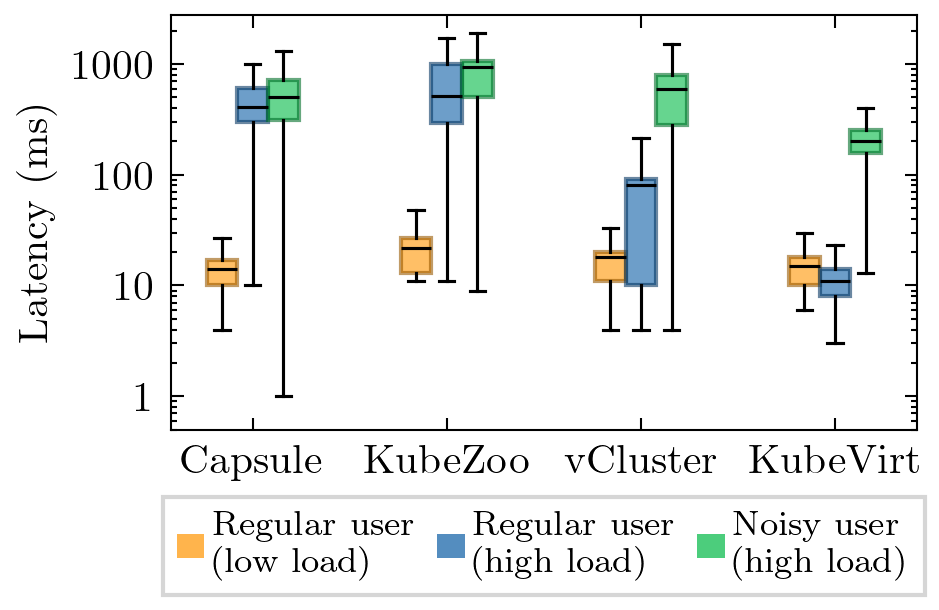


COMPARATIVE LATENCY ANALYSIS

KUBEVIRT:
  Baseline:
    Requests: 3,006
    Mean: 14.9ms
    Median: 15.0ms
    P95: 23.0ms
    P99: 28.9ms
    Std Dev: 5.2ms
  Regular Tenant:
    Requests: 9,002
    Mean: 11.4ms
    Median: 11.0ms
    P95: 18.0ms
    P99: 22.0ms
    Std Dev: 3.9ms
  Malicious Tenant:
    Requests: 420,726
    Mean: 214.1ms
    Median: 201.0ms
    P95: 354.0ms
    P99: 492.0ms
    Std Dev: 102.3ms


In [20]:
# plot all comparative latency distribution
plot_comparative_latency_distribution(
    data_dirs="./final",
    save_plots=True,
    out_dir="./plots",
)

Loading data from all solutions for regular tenant comparison...
Loaded 3 experiments
Loaded 3 experiments
Processing capsule: 3304 regular tenant requests
  capsule: plotted 240 time points
Loaded 3 experiments
Loaded 3 experiments
Processing kubezoo: 2896 regular tenant requests
  kubezoo: plotted 239 time points
Loaded 3 experiments
Loaded 3 experiments
Processing vcluster: 6213 regular tenant requests
  vcluster: plotted 240 time points
Loaded 3 experiments
Loaded 3 experiments
Processing kubevirt: 12002 regular tenant requests
  kubevirt: plotted 240 time points


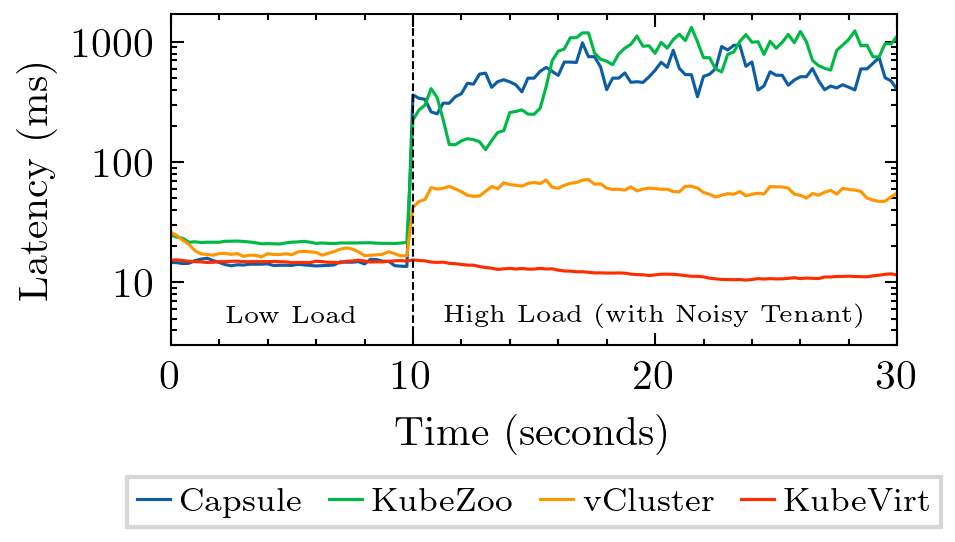

In [21]:
plot_regular_tenant_comparison_across_solutions(
    data_dirs="./final",
    save_plots=True,
    out_dir="./plots",
    single_column_size=True,
    max_duration=30
)

Loaded 3 experiments
Found 3 stress test experiments for capsule
Loaded 152148 total records for capsule across all experiments
Loaded 3 experiments
Found 3 stress test experiments for kubezoo
Loaded 104520 total records for kubezoo across all experiments
Loaded 3 experiments
Found 3 stress test experiments for vcluster
Loaded 170031 total records for vcluster across all experiments
Loaded 3 experiments
Found 3 stress test experiments for kubevirt
Loaded 429728 total records for kubevirt across all experiments


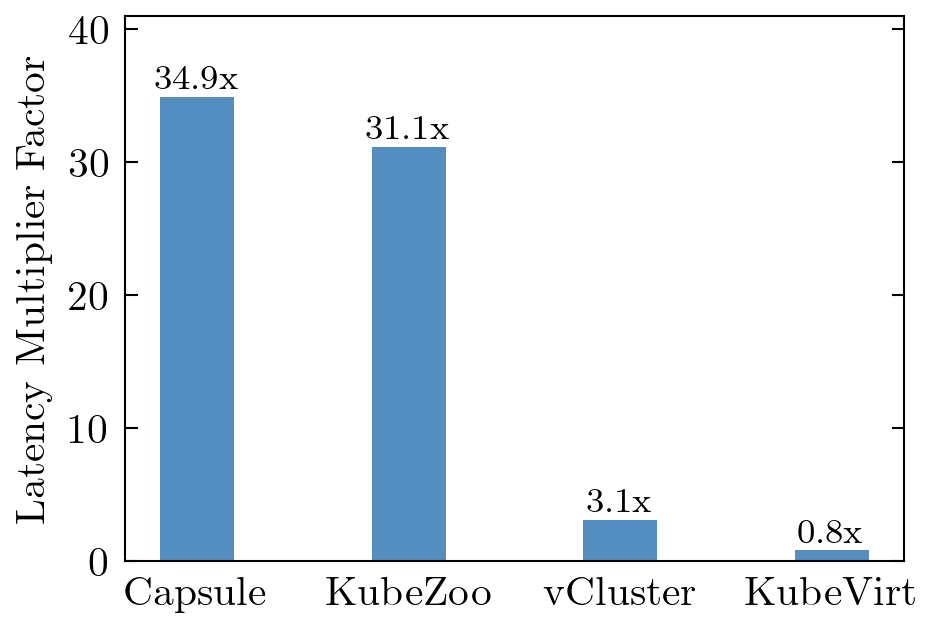


RELATIVE MULTIPLIER FACTOR ANALYSIS - ALL EXPERIMENTS

CAPSULE (Capsule):
  Total Experiments: 3
  Regular Tenant Multiplier Factor:
    Total Requests: 354
    Mean: 34.89x
    Median: 28.57x
    Std Dev: 25.19
    Min: 0.67x
    Max: 174.00x
    P95: 88.50x
    P99: 130.72x
    Performance: ❌ Poor
  Malicious Tenant Multiplier Factor:
    Total Requests: 151,794
    Mean: 40.94x
    Median: 34.40x
    Std Dev: 27.76
    Min: 0.07x
    Max: 399.71x
    P95: 93.14x
    P99: 146.67x
    Performance: ❌ Poor

KUBEZOO (KubeZoo):
  Total Experiments: 3
  Regular Tenant Multiplier Factor:
    Total Requests: 268
    Mean: 31.13x
    Median: 23.95x
    Std Dev: 21.83
    Min: 0.50x
    Max: 77.95x
    P95: 71.15x
    P99: 75.42x
    Performance: ❌ Poor
  Malicious Tenant Multiplier Factor:
    Total Requests: 104,252
    Mean: 40.46x
    Median: 43.64x
    Std Dev: 19.15
    Min: 0.43x
    Max: 222.52x
    P95: 71.43x
    P99: 78.62x
    Performance: ❌ Poor

VCLUSTER (vCluster):
  Total Expe

In [231]:
# Plot multiplier factor comparison across all solutions
plot_multiplier_factor_comparison(
    data_dirs="./final",
    save_plots=True,
    out_dir="./plots",
    single_column_size=True
)

Loaded 3 experiments
Found 3 stress test experiments for capsule
Loaded 152148 total records for capsule across all experiments
Loaded 3 experiments
Found 3 stress test experiments for kubezoo
Loaded 104520 total records for kubezoo across all experiments
Loaded 3 experiments
Found 3 stress test experiments for vcluster
Loaded 170031 total records for vcluster across all experiments
Loaded 3 experiments
Found 3 stress test experiments for kubevirt
Loaded 429728 total records for kubevirt across all experiments


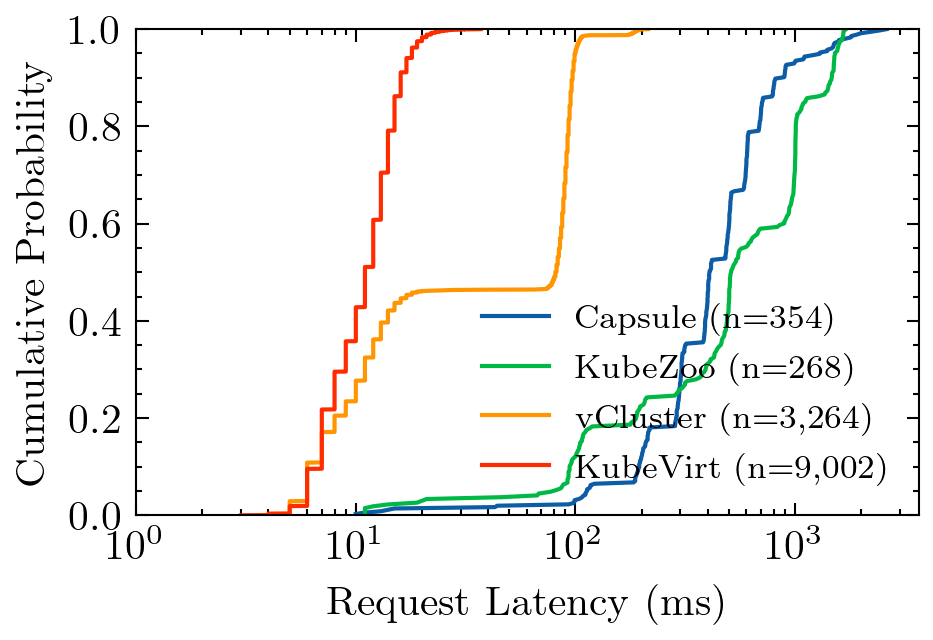


REGULAR TENANT CDF ANALYSIS - ALL EXPERIMENTS

CAPSULE:
  Total Experiments: 3
  Regular Tenant CDF Percentiles:
    Total Requests: 354
    P50 (Median): 408.0ms
    P90: 867.6ms
    P95: 1295.1ms
    P99: 1947.0ms
    P99.9: 2540.5ms
    % under 10ms: 0.3%
    % under 100ms: 3.1%
    % under 1000ms: 93.2%

KUBEZOO:
  Total Experiments: 3
  Regular Tenant CDF Percentiles:
    Total Requests: 268
    P50 (Median): 511.5ms
    P90: 1467.5ms
    P95: 1519.2ms
    P99: 1655.7ms
    P99.9: 1694.1ms
    % under 10ms: 0.0%
    % under 100ms: 11.9%
    % under 1000ms: 73.1%

VCLUSTER:
  Total Experiments: 3
  Regular Tenant CDF Percentiles:
    Total Requests: 3,264
    P50 (Median): 81.0ms
    P90: 97.0ms
    P95: 100.0ms
    P99: 180.0ms
    P99.9: 197.7ms
    % under 10ms: 27.7%
    % under 100ms: 95.7%
    % under 1000ms: 100.0%

KUBEVIRT:
  Total Experiments: 3
  Regular Tenant CDF Percentiles:
    Total Requests: 9,002
    P50 (Median): 11.0ms
    P90: 16.0ms
    P95: 18.0ms
    P99: 2

In [ ]:
plot_comparative_cdf(
    data_dirs="./final",
    save_plots=True,
    out_dir="./plots",
    single_column_size=True
)

## Plot the data using Capsule

Loaded 1001 baseline request records
Loaded 50007 stress test request records
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ❌ FAILED

Test Configuration:
  Regular Requesters: 1
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 49,894
    Average Latency: 607.4ms
    Median Latency: 502.0ms
    95th Percentile: 1399.0ms
    Standard Deviation: 418.8ms
    Error Rate: 0.00%
    Successful Requests: 49,894
    Failed Requests: 0

  Regular Tenant:
    Total Requests: 113
    Average Latency: 537.8ms
    Median Latency: 415.0ms
    95th Percentile: 1493.4ms
    Standard Deviation: 391.6ms
    Error Rate: 0.88%
    Successful Requests: 112
    Failed Requests: 1

Baseline Comparison:
  Baseline Latency: 14.0ms
  Current Avg Latency: 537.8ms
  Relative Increase: 3741.7%

Generating baseline vs stress comparison plot...
Plotting combined

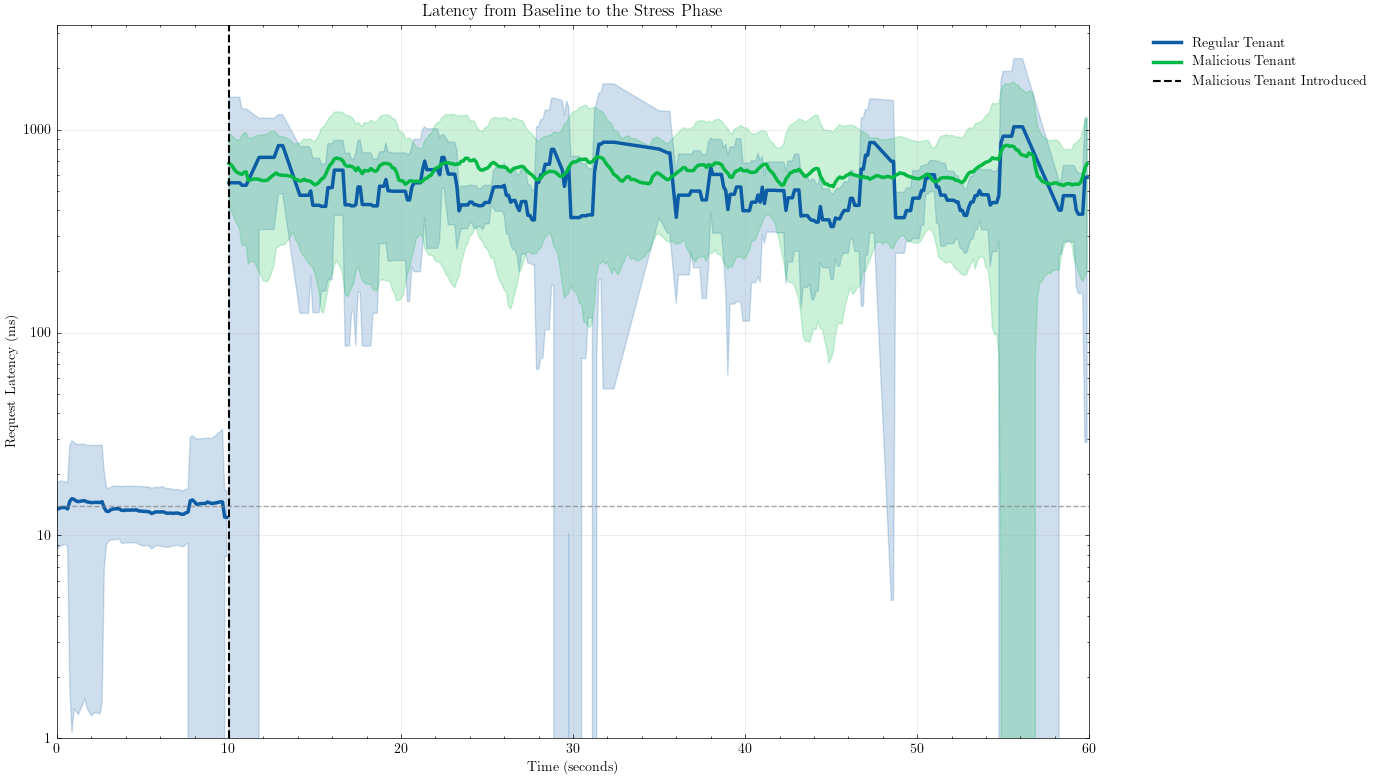


BASELINE TO STRESS TRANSITION ANALYSIS

BASELINE PHASE (0-10s):
  Regular Tenant: 13.7ms avg, 1000 requests
  Malicious Tenant: 444.0ms avg, 1 requests

STRESS TEST PHASE (10s-60s):
  Malicious Tenant: 607.4ms avg (+36.8%), 49893 requests
  Regular Tenant: 537.8ms avg (+3825.3%), 113 requests


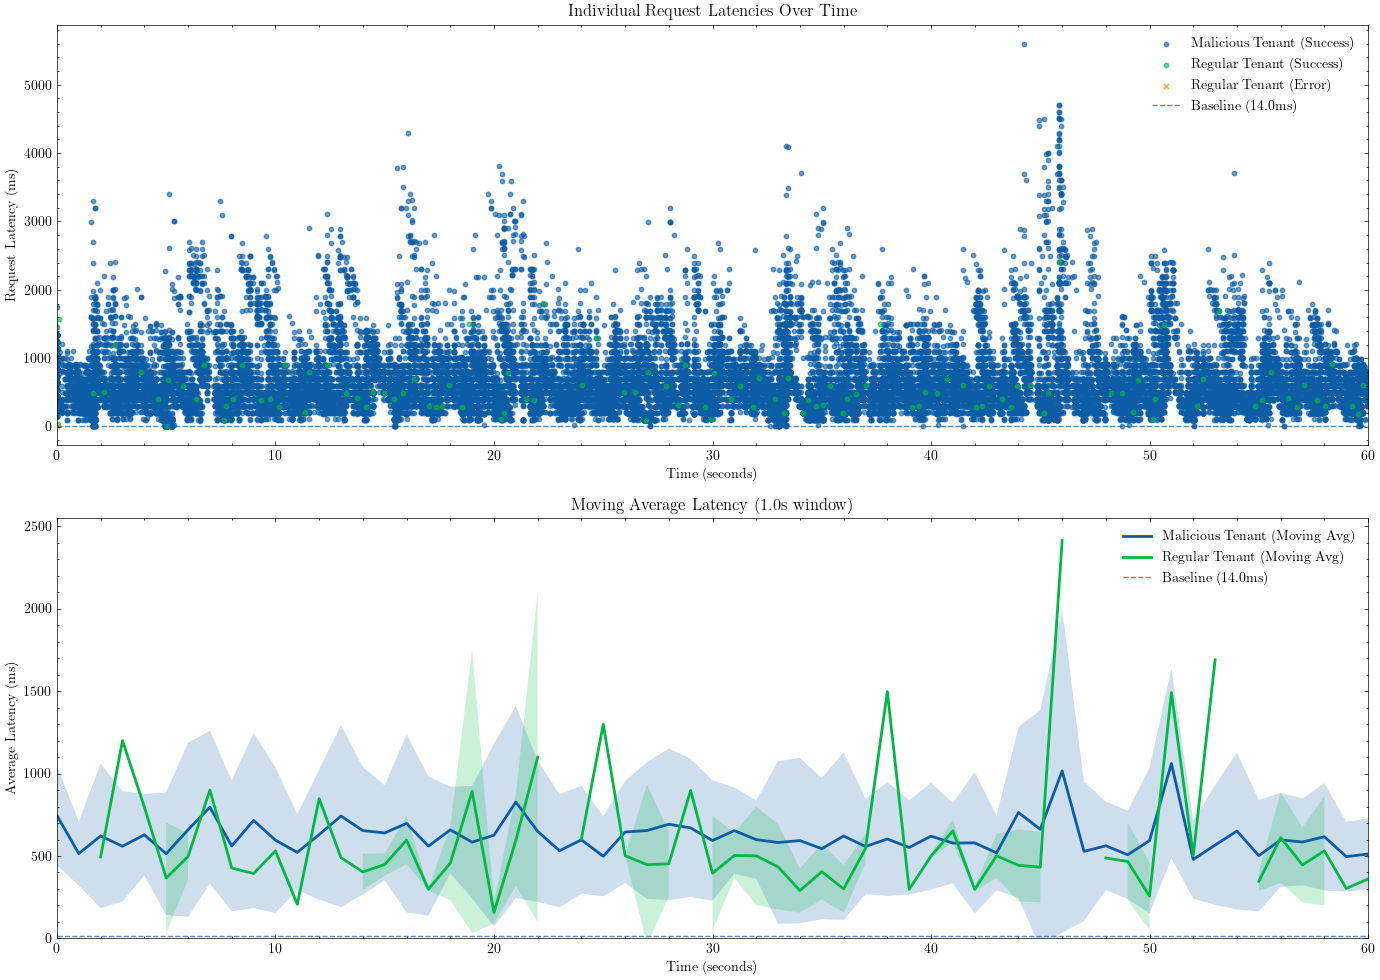

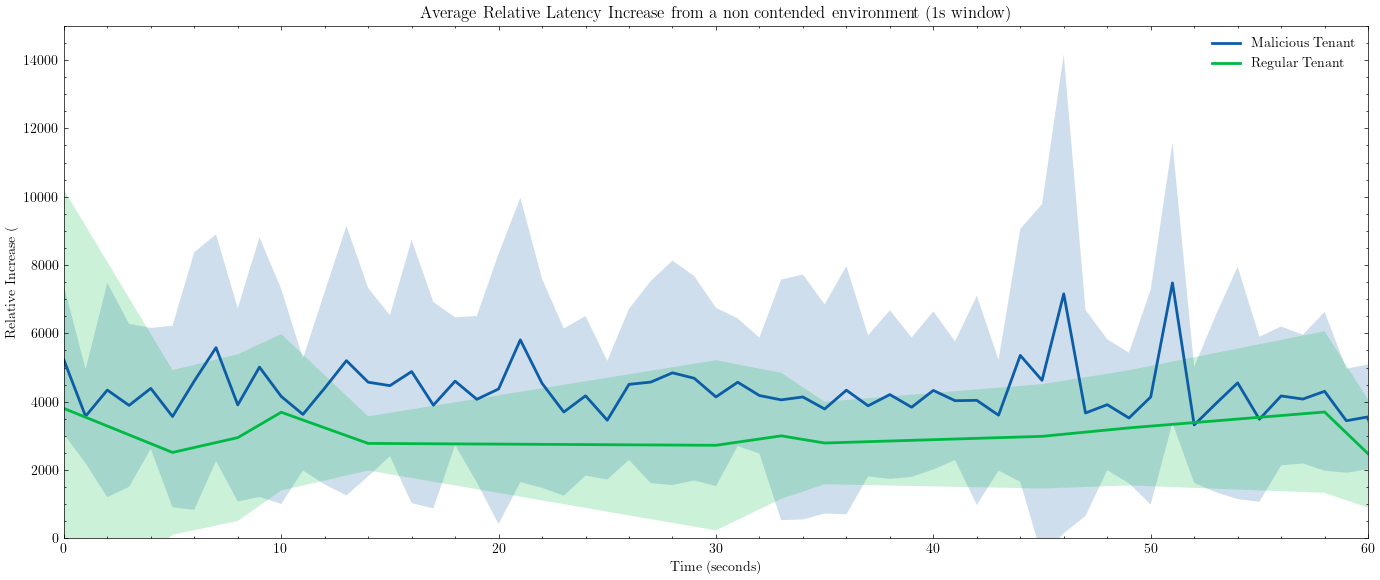

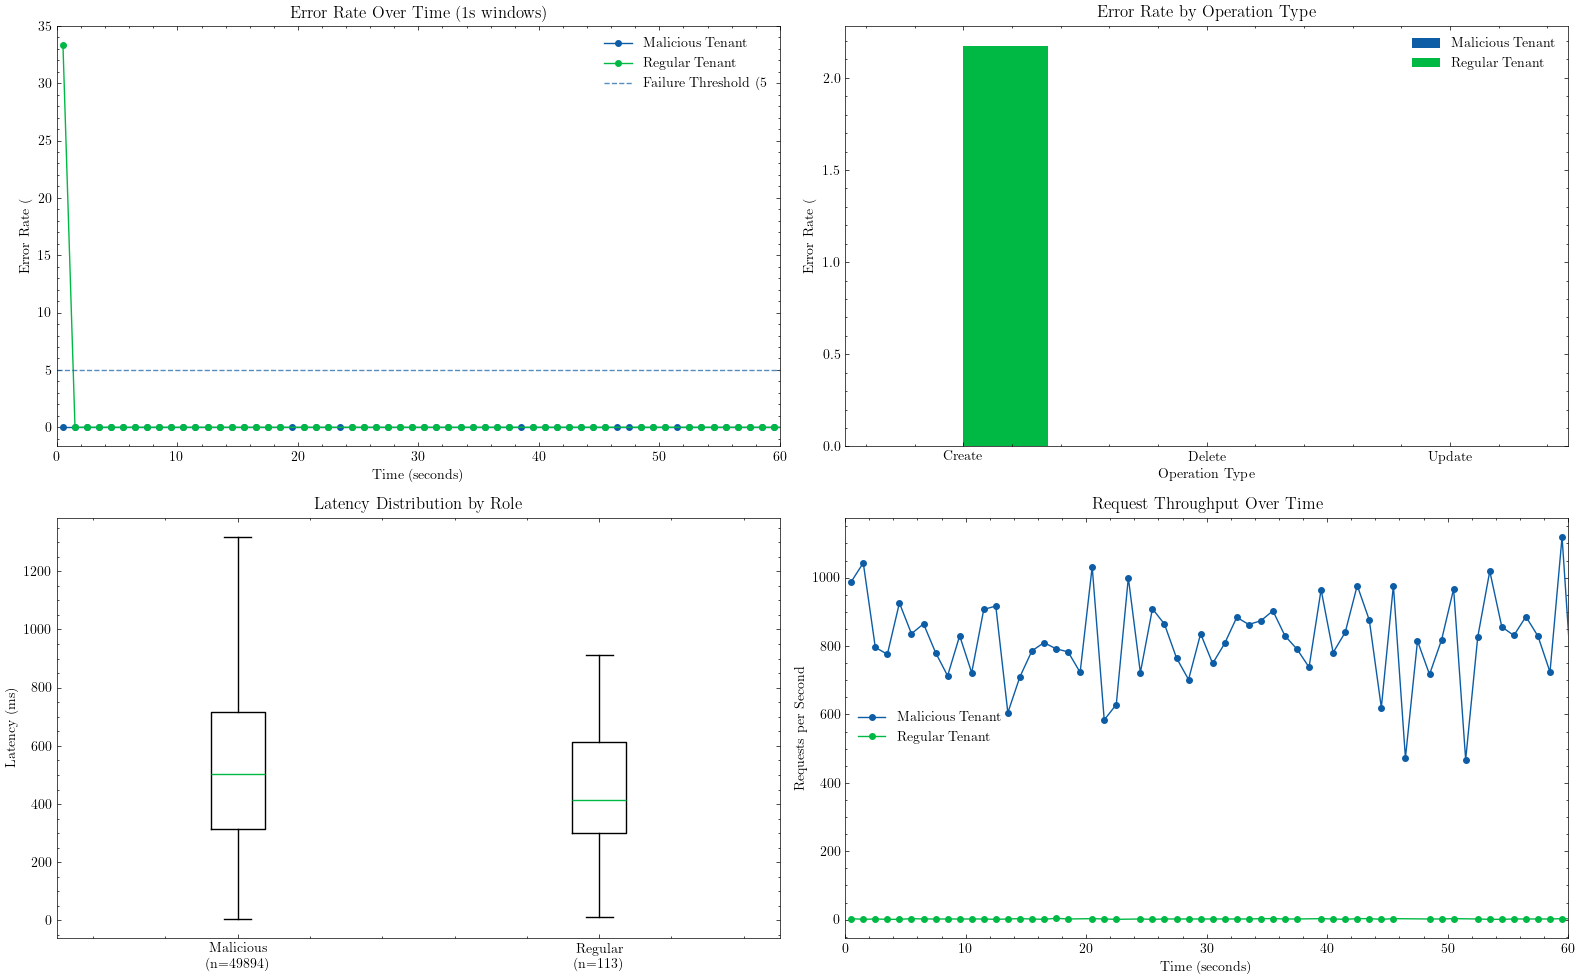

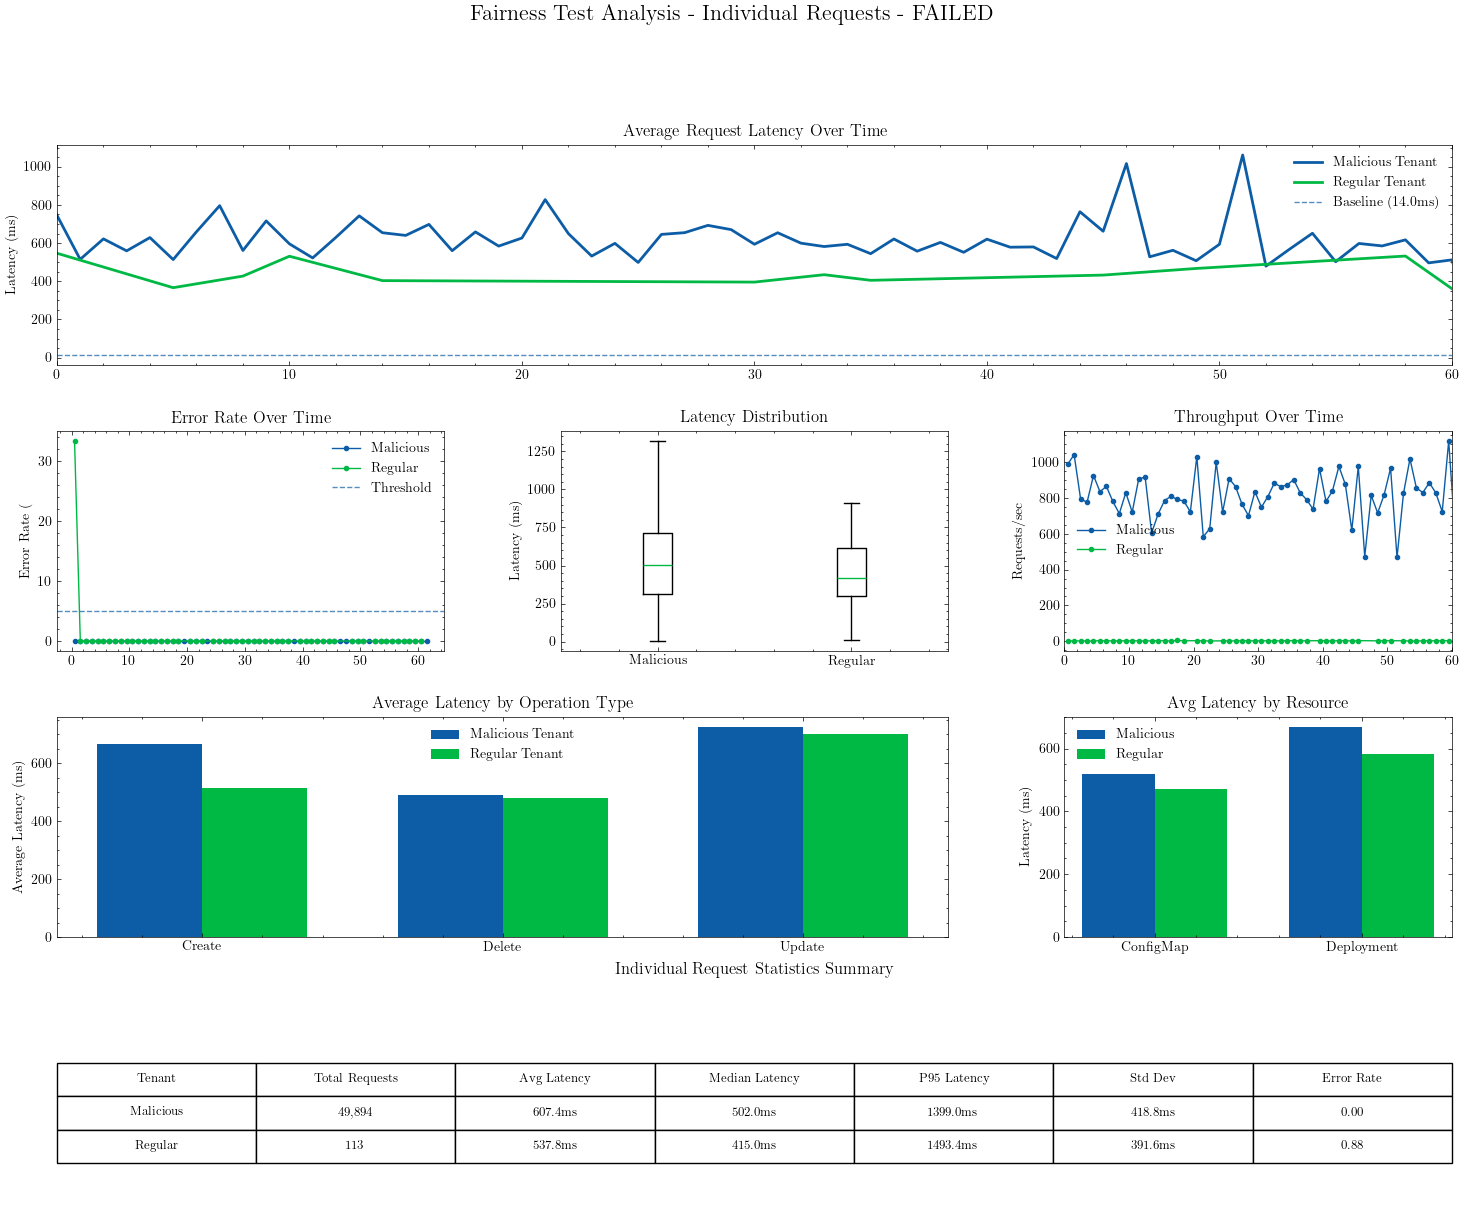


Analysis complete! Plots saved with timestamp: 1750293921_1750293921


(      start_time     role  duration_ms operation    resource  is_error  \
 0       0.000481  Regular           17    Create  Deployment     False   
 1       0.000578  Regular           18    Create  Deployment     False   
 2       0.021104  Regular            9    Create   ConfigMap     False   
 3       0.021158  Regular            9    Create   ConfigMap     False   
 4       0.041617  Regular           17    Update  Deployment     False   
 ...          ...      ...          ...       ...         ...       ...   
 996     9.961636  Regular            7    Delete   ConfigMap     False   
 997     9.961777  Regular            6    Delete   ConfigMap     False   
 998     9.981600  Regular            6    Delete  Deployment     False   
 999     9.981600  Regular            6    Delete  Deployment     False   
 1000   10.000835  Regular           13    Create  Deployment     False   
 
       elapsed_seconds  duration_seconds     phase  
 0            0.000000             0.017  bas

In [ ]:
# Run the analysis
analyze_fairness_test("./final/capsule/data", "./final/capsule/results")

## Plot the data using vCluster

Loaded 948 baseline request records
Loaded 59595 stress test request records
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ❌ FAILED

Test Configuration:
  Regular Requesters: 1
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 58,498
    Average Latency: 519.4ms
    Median Latency: 585.0ms
    95th Percentile: 910.0ms
    Standard Deviation: 281.4ms
    Error Rate: 0.00%
    Successful Requests: 58,498
    Failed Requests: 0

  Regular Tenant:
    Total Requests: 1,097
    Average Latency: 54.2ms
    Median Latency: 80.0ms
    95th Percentile: 99.0ms
    Standard Deviation: 43.6ms
    Error Rate: 0.00%
    Successful Requests: 1,097
    Failed Requests: 0

Baseline Comparison:
  Baseline Latency: 18.0ms
  Current Avg Latency: 54.2ms
  Relative Increase: 201.0%

Generating baseline vs stress comparison plot...
Plotting combined time

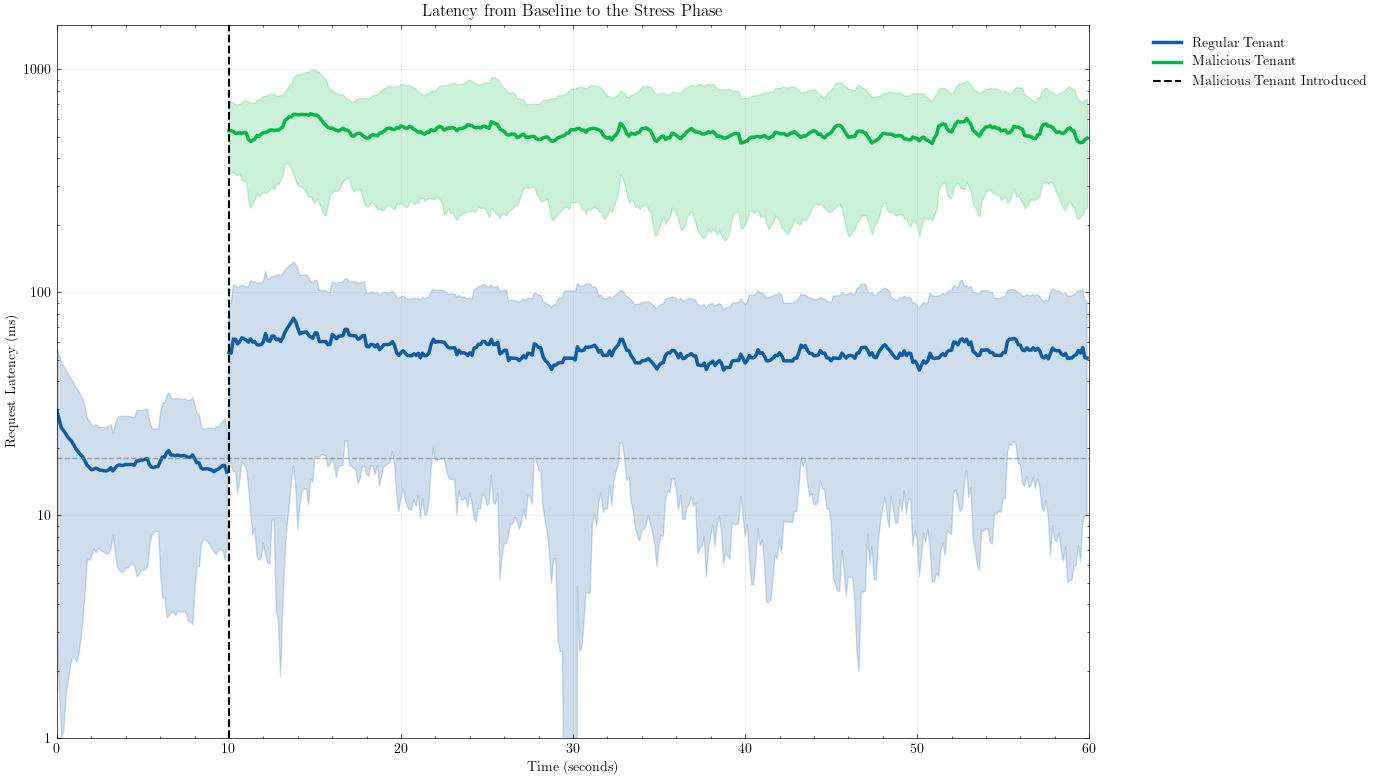


BASELINE TO STRESS TRANSITION ANALYSIS

BASELINE PHASE (0-10s):
  Regular Tenant: 17.8ms avg, 948 requests
  Malicious Tenant: 252.0ms avg, 1 requests

STRESS TEST PHASE (10s-60s):
  Regular Tenant: 54.2ms avg (+204.5%), 1097 requests
  Malicious Tenant: 519.4ms avg (+106.1%), 58497 requests


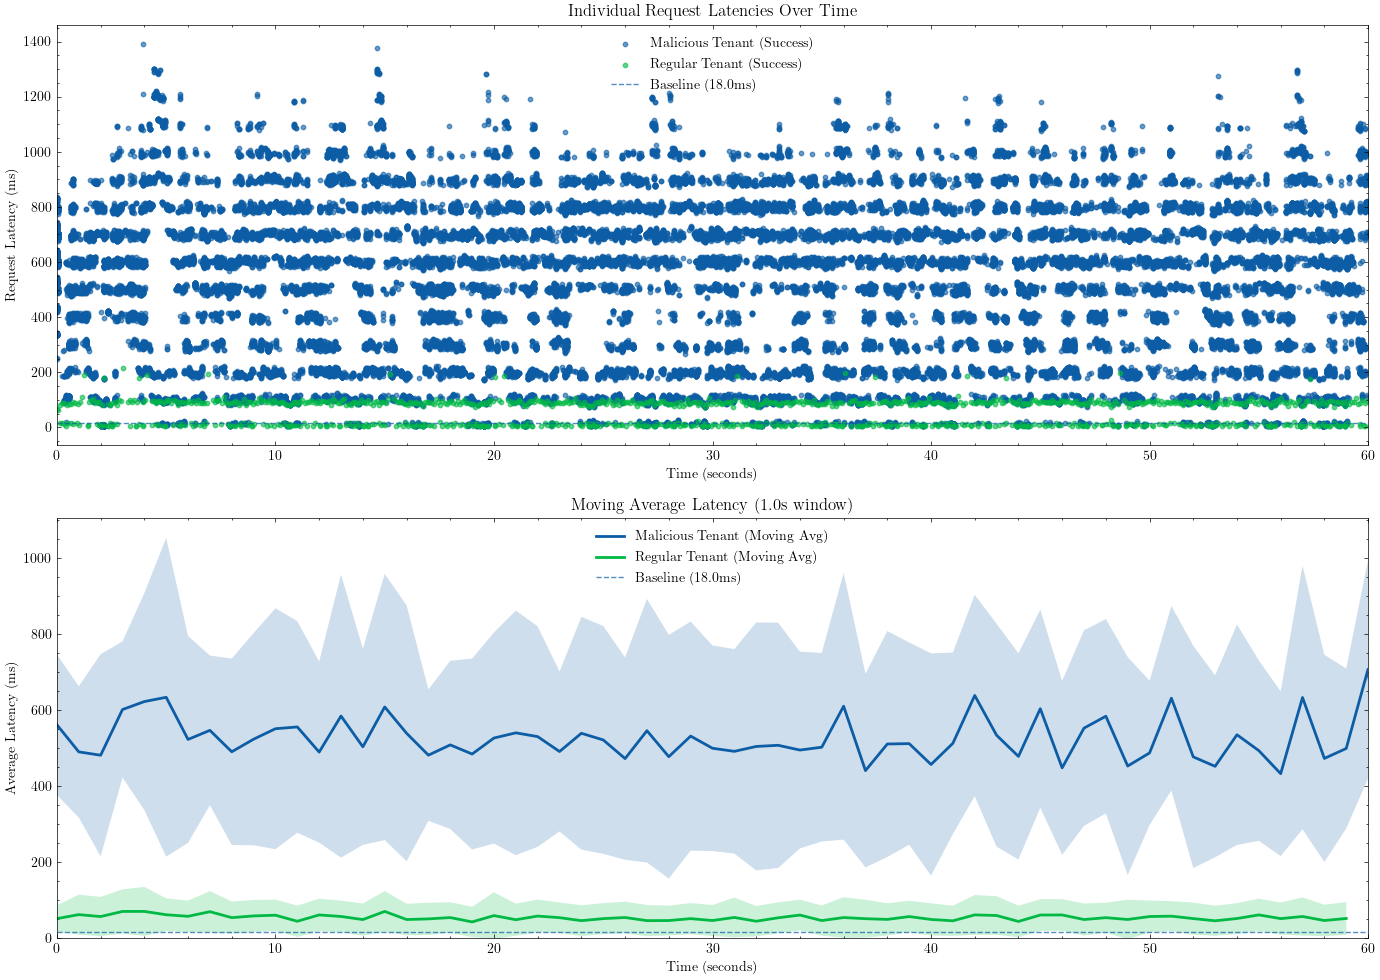

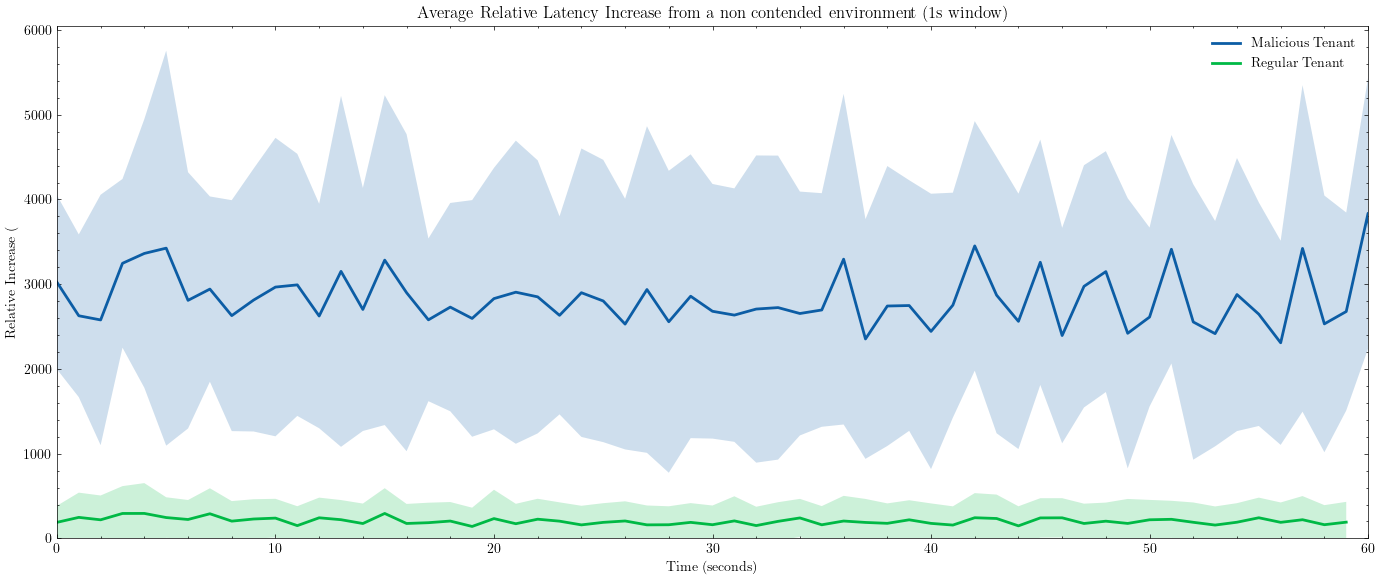

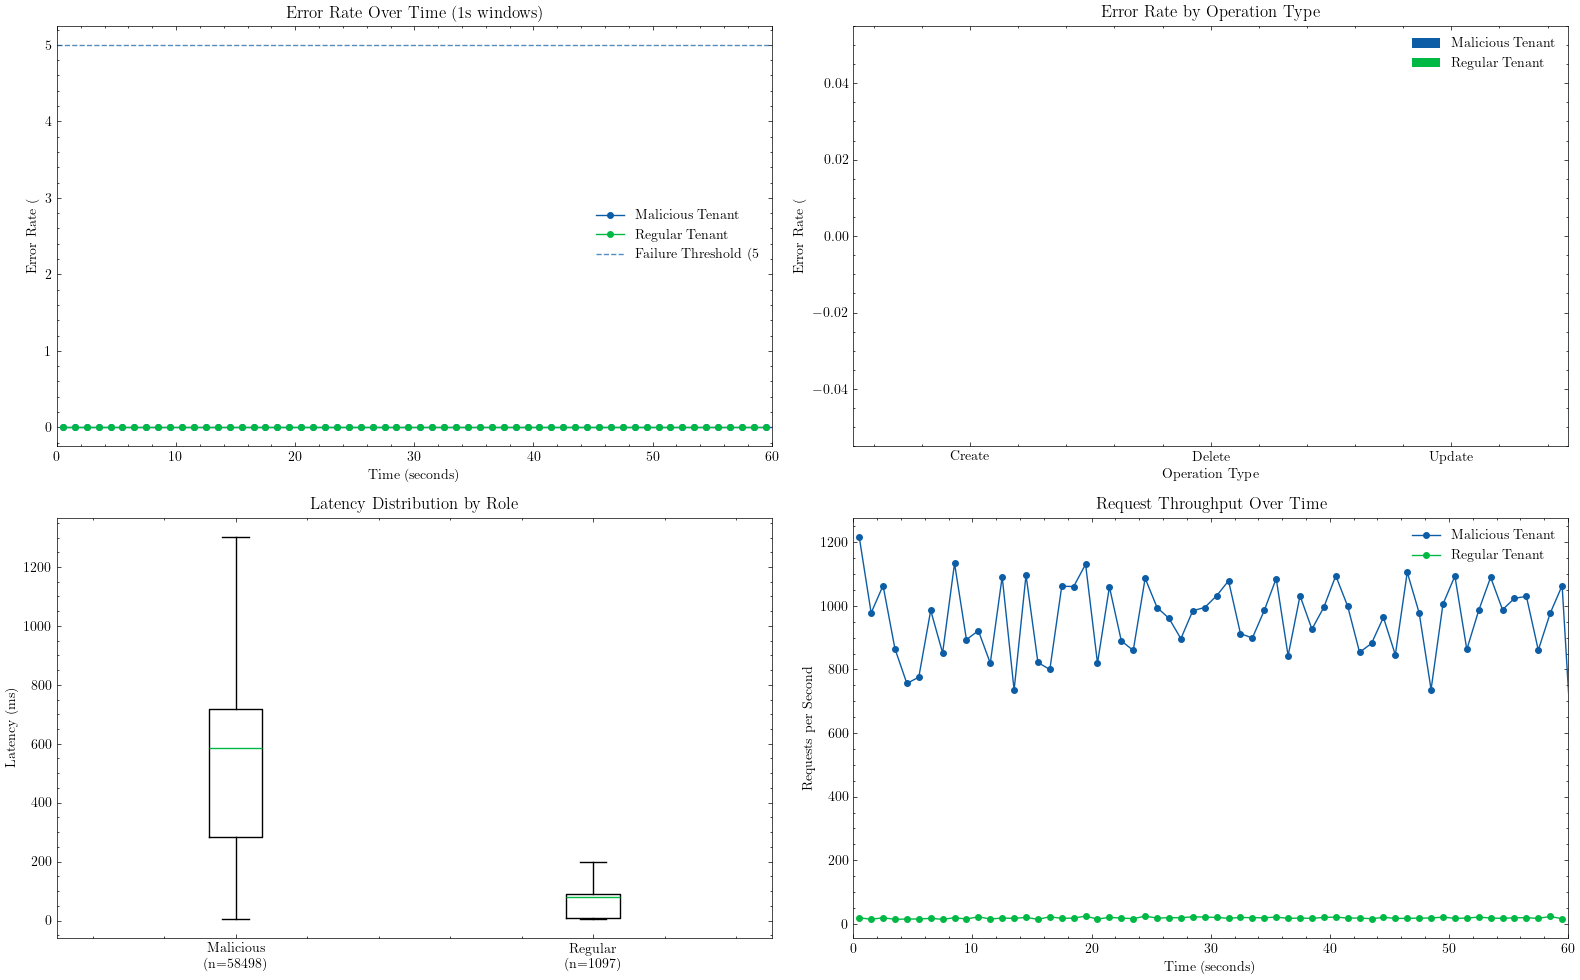

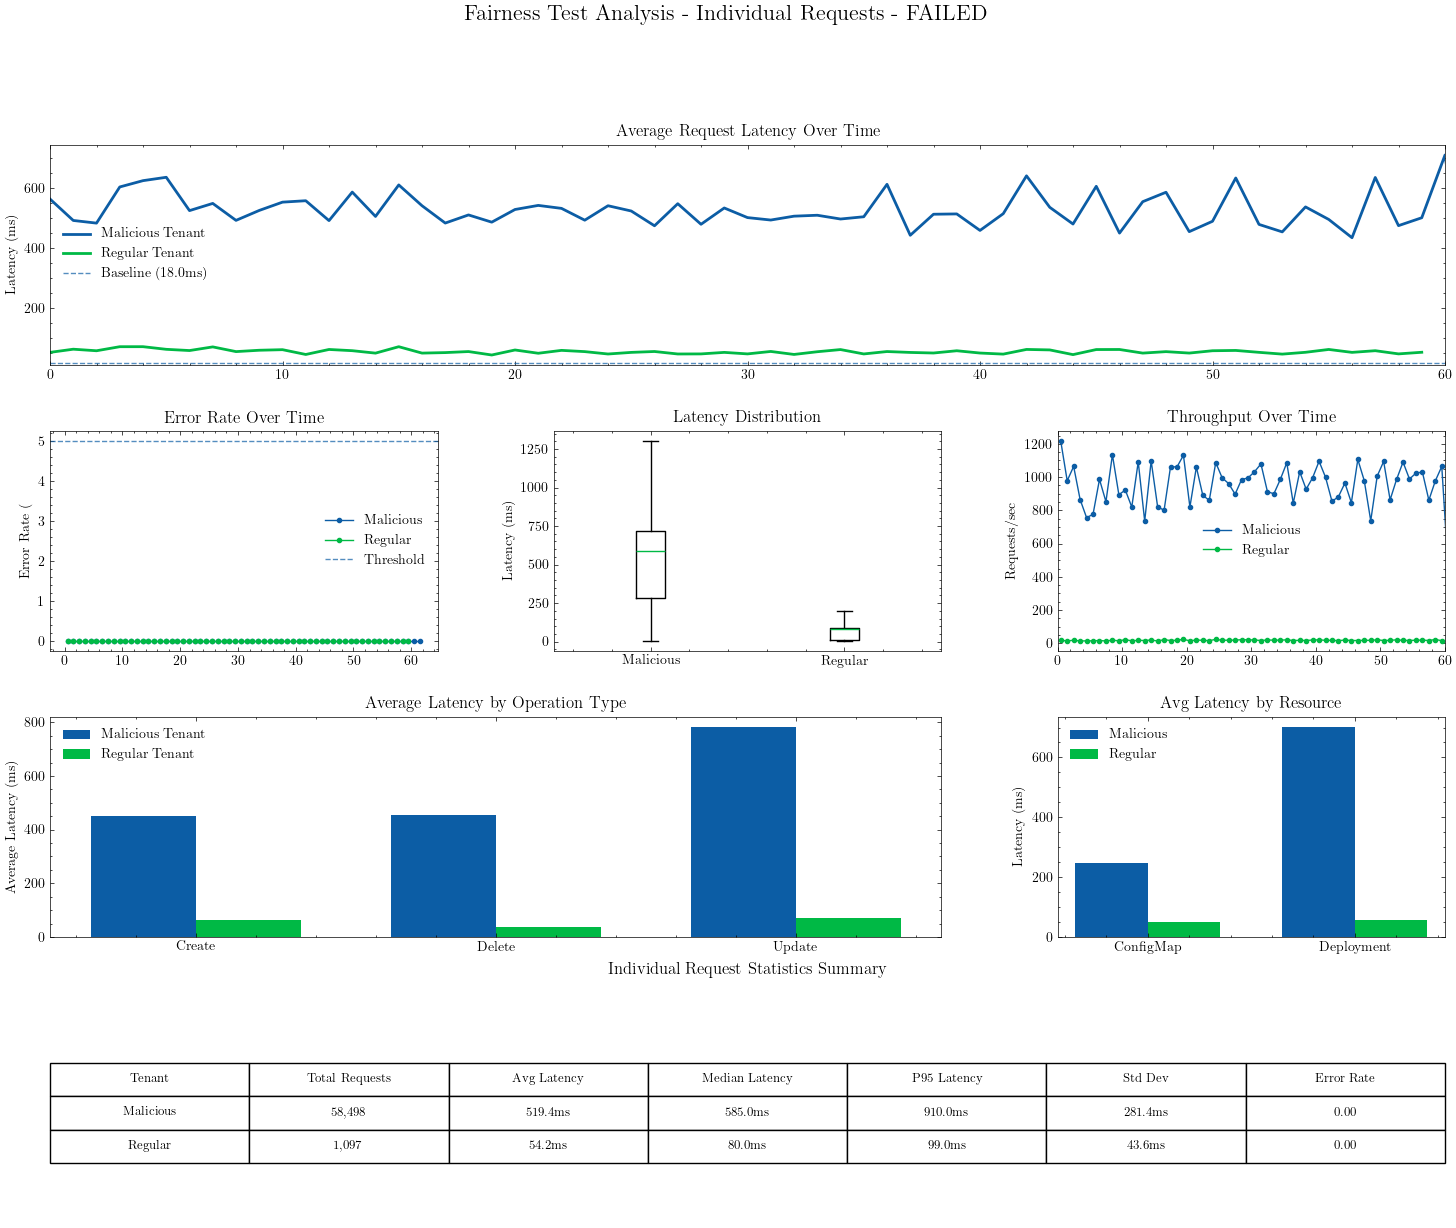


Analysis complete! Plots saved with timestamp: 1750295120_1750295120


(     start_time     role  duration_ms operation    resource  is_error  \
 0      0.000570  Regular           23    Create  Deployment     False   
 1      0.001617  Regular           20    Create  Deployment     False   
 2      0.022536  Regular           12    Create   ConfigMap     False   
 3      0.024108  Regular           11    Create   ConfigMap     False   
 4      0.041254  Regular            9    Update  Deployment     False   
 ..          ...      ...          ...       ...         ...       ...   
 943    9.901213  Regular           18    Create  Deployment     False   
 944    9.921504  Regular           15    Create   ConfigMap     False   
 945    9.941058  Regular           20    Update  Deployment     False   
 946    9.961622  Regular           10    Delete   ConfigMap     False   
 947    9.981135  Regular           10    Delete  Deployment     False   
 
      elapsed_seconds  duration_seconds     phase  
 0           0.000000             0.023  baseline  
 1    

In [ ]:
# Run the analysis
analyze_fairness_test("./final/vcluster/data", "./final/vcluster/results")

## Plot the data using KubeZoo

Loaded 6690 baseline request records
Loaded 35900 stress test request records
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 35,212
    Average Latency: 864.0ms
    Median Latency: 1018.0ms
    95th Percentile: 1531.0ms
    Standard Deviation: 364.6ms
    Error Rate: 0.00%
    Successful Requests: 35,212
    Failed Requests: 0

  Regular Tenant:
    Total Requests: 688
    Average Latency: 889.1ms
    Median Latency: 1018.0ms
    95th Percentile: 1531.0ms
    Standard Deviation: 449.5ms
    Error Rate: 1.60%
    Successful Requests: 677
    Failed Requests: 11

Baseline Comparison:
  Baseline Latency: 26.0ms
  Current Avg Latency: 889.1ms
  Relative Increase: 3319.6%

Generating baseline vs stress comparison plot...
Plotting comb

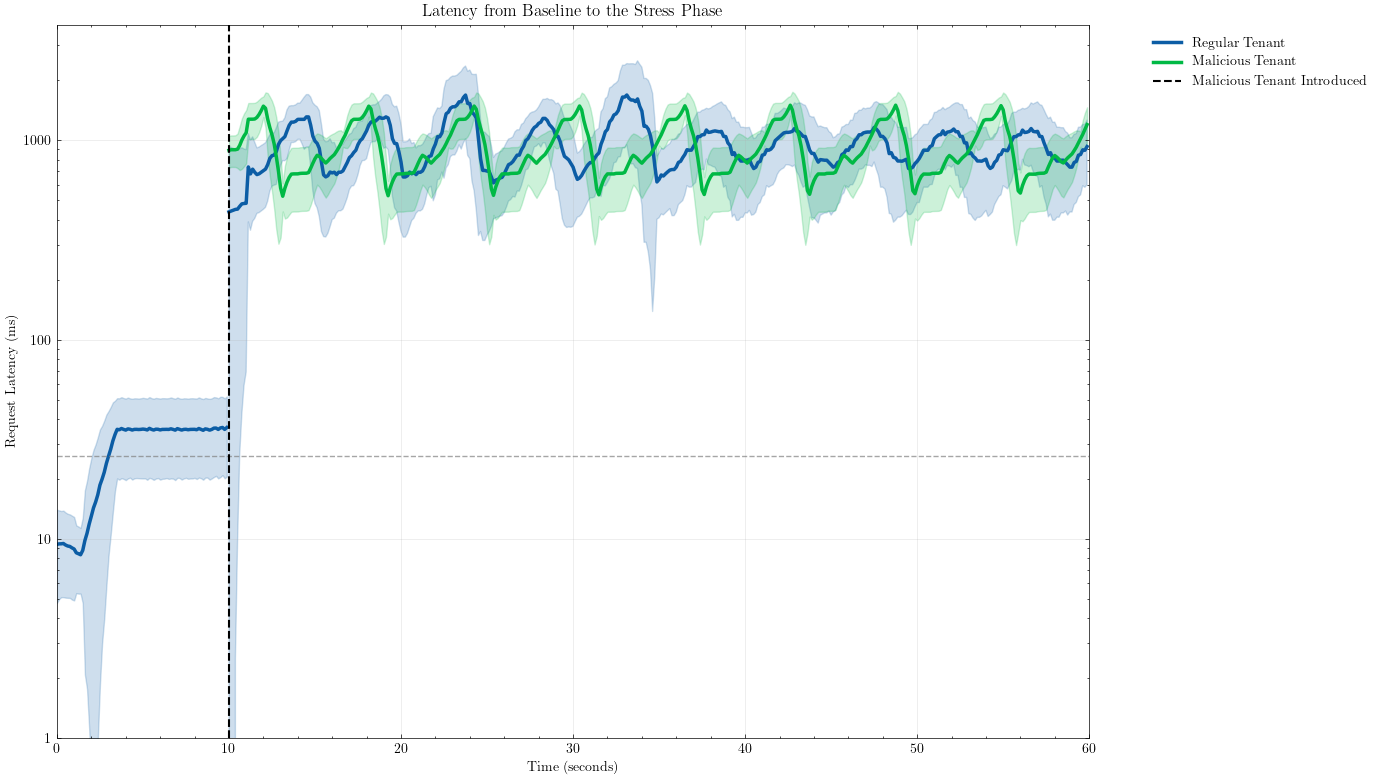


BASELINE TO STRESS TRANSITION ANALYSIS

BASELINE PHASE (0-10s):
  Regular Tenant: 25.6ms avg, 6660 requests
  Malicious Tenant: 495.0ms avg, 1 requests

STRESS TEST PHASE (10s-60s):
  Regular Tenant: 889.1ms avg (+3368.7%), 688 requests
  Malicious Tenant: 864.0ms avg (+74.6%), 35211 requests


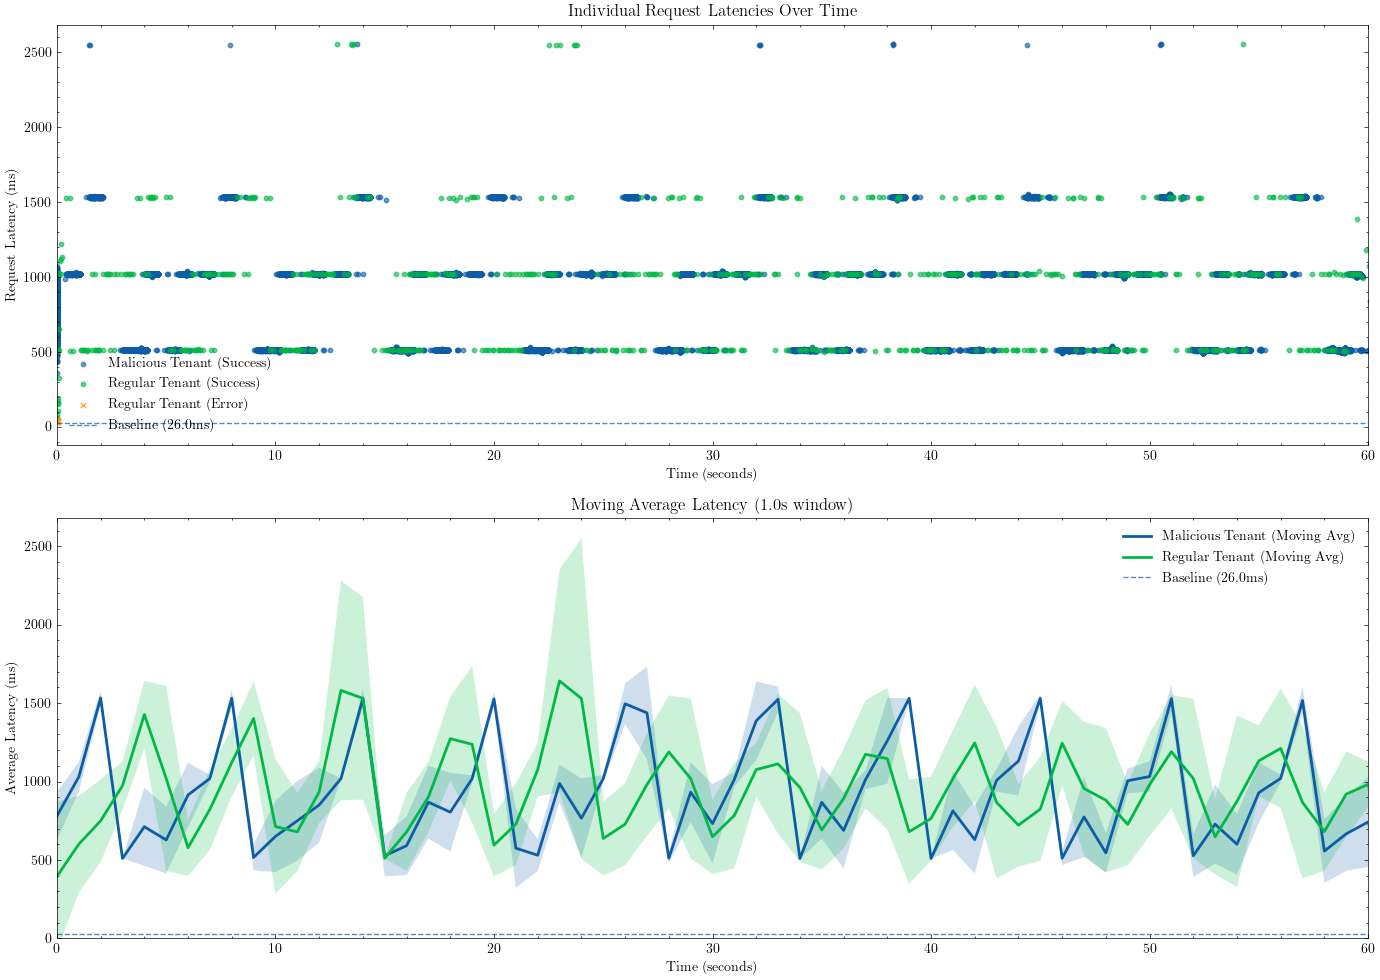

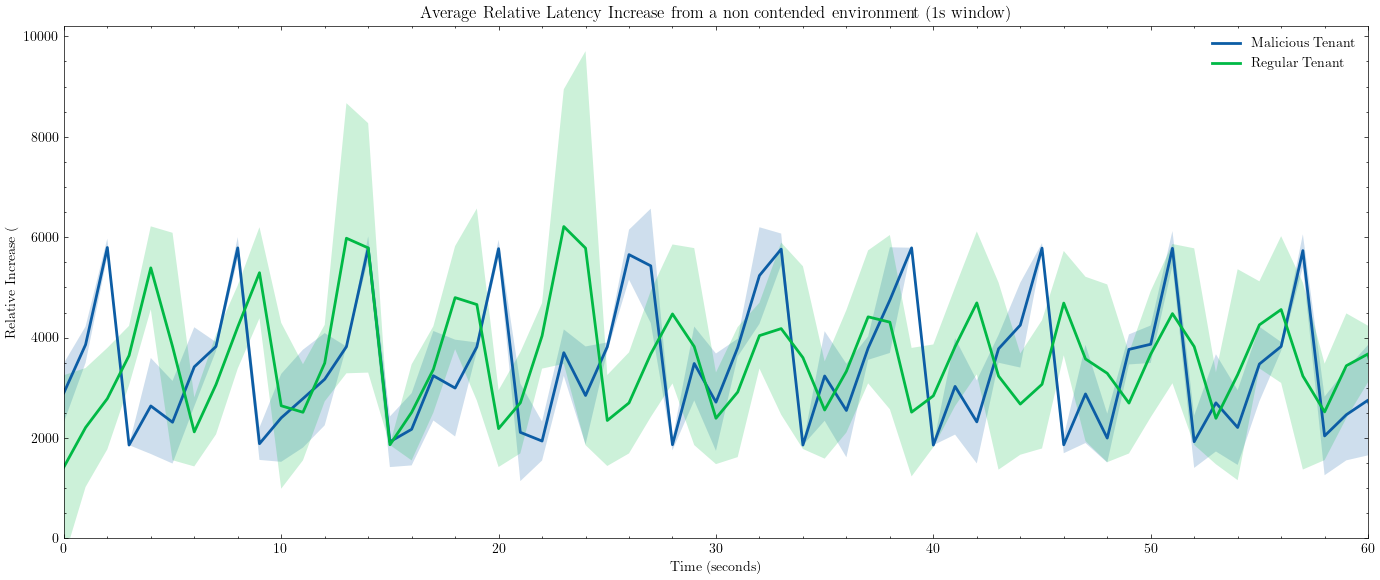

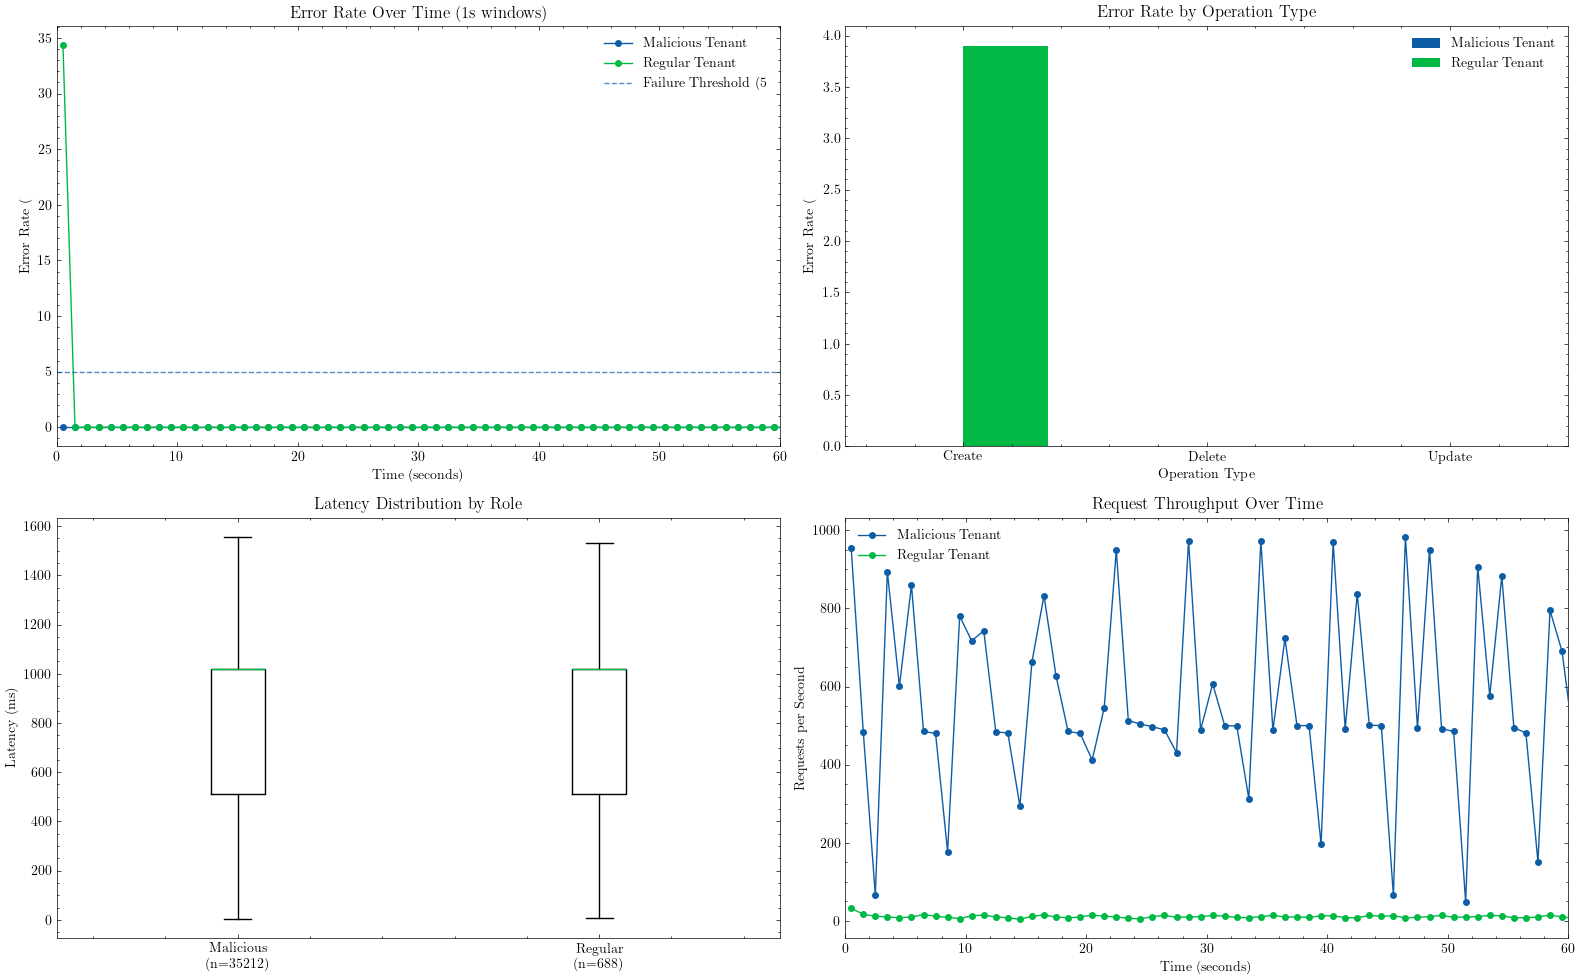

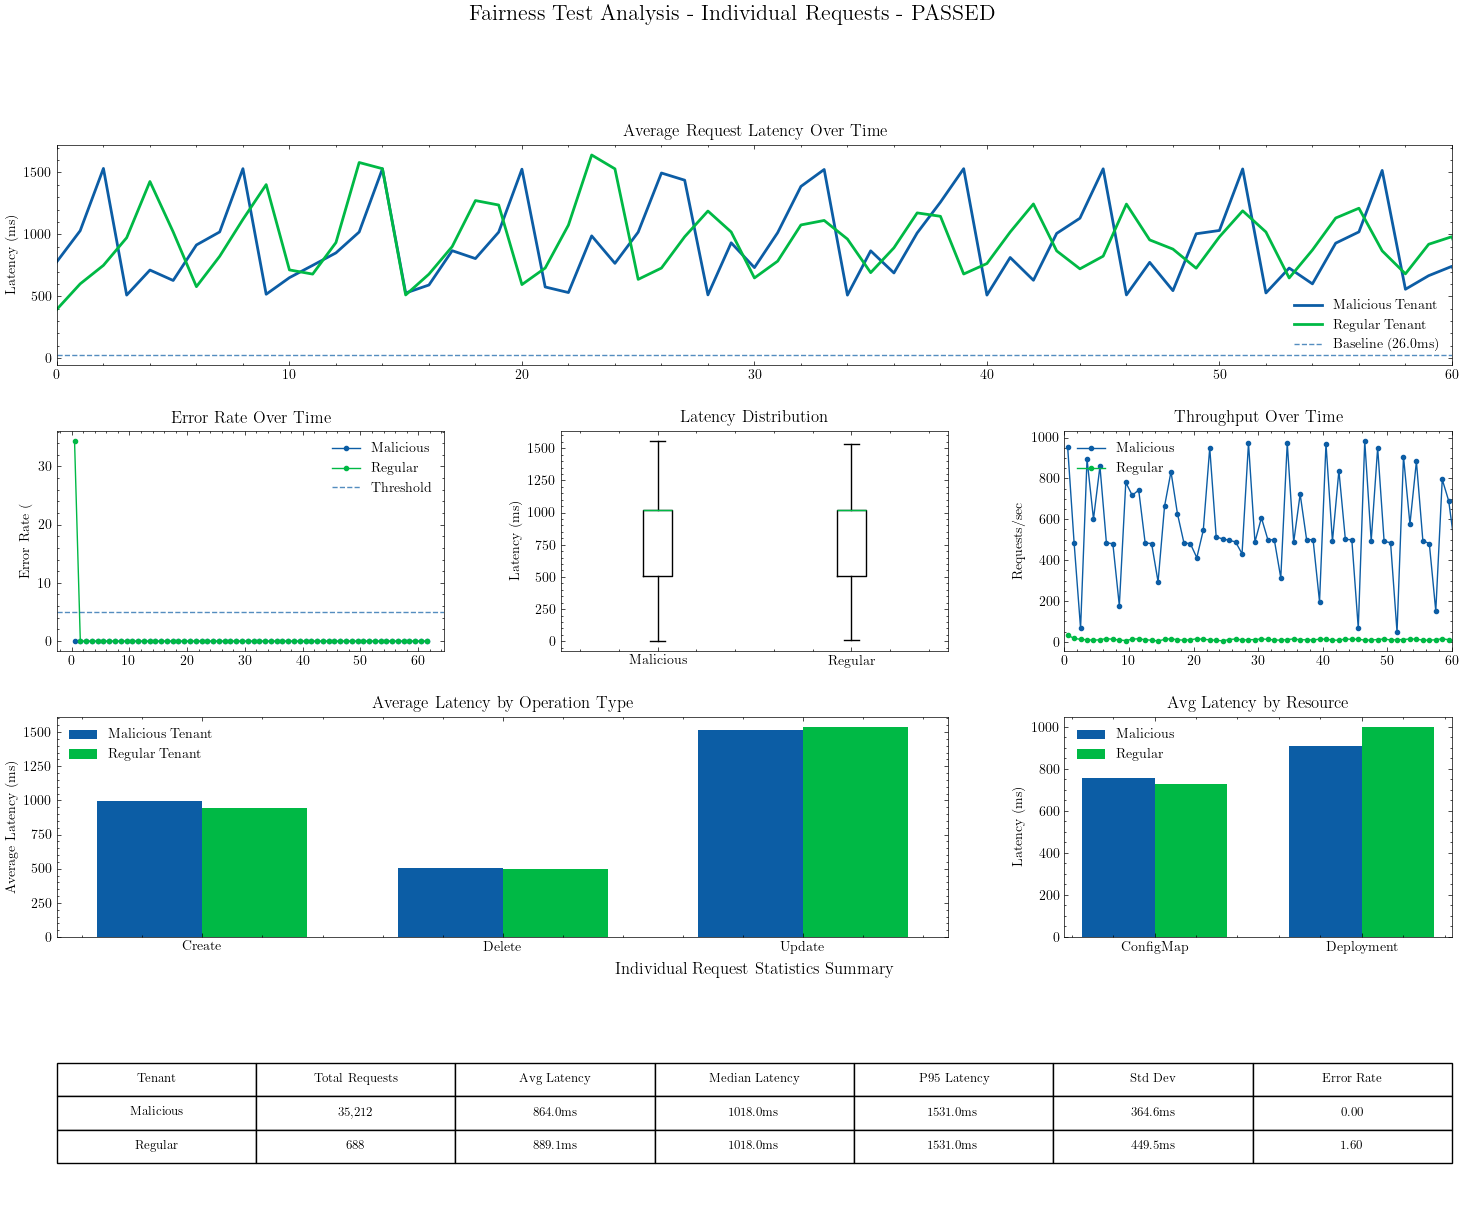


Analysis complete! Plots saved with timestamp: 1750007207_1750007207


(      start_time     role  duration_ms operation    resource  is_error  \
 0       0.002421  Regular           31    Create  Deployment     False   
 1       0.002427  Regular           31    Create  Deployment     False   
 2       0.002440  Regular           32    Create  Deployment     False   
 3       0.002448  Regular           34    Create  Deployment     False   
 4       0.002472  Regular           34    Create  Deployment     False   
 ...          ...      ...          ...       ...         ...       ...   
 6685   10.059665  Regular            6    Create  Deployment     False   
 6686   10.063166  Regular            5    Create   ConfigMap     False   
 6687   10.064661  Regular            5    Create   ConfigMap     False   
 6688   10.068761  Regular            7    Update  Deployment     False   
 6689   10.076731  Regular            3    Delete   ConfigMap     False   
 
       elapsed_seconds  duration_seconds     phase  
 0            0.000000             0.031  bas

In [ ]:
# Run the analysis
analyze_fairness_test("./60_sec/kubezoo/data", "./60_sec/kubezoo/results")

Loaded 8389 baseline request records
Loaded 114045 stress test request records
FAIRNESS TEST SUMMARY - INDIVIDUAL REQUEST ANALYSIS
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 60s

Individual Request Statistics:

  Malicious Tenant:
    Total Requests: 84,038
    Average Latency: 358.8ms
    Median Latency: 346.0ms
    95th Percentile: 563.0ms
    Standard Deviation: 115.6ms
    Error Rate: 0.00%
    Successful Requests: 84,038
    Failed Requests: 0

  Regular Tenant:
    Total Requests: 30,007
    Average Latency: 16.0ms
    Median Latency: 15.0ms
    95th Percentile: 30.0ms
    Standard Deviation: 7.5ms
    Error Rate: 0.04%
    Successful Requests: 29,996
    Failed Requests: 11

Baseline Comparison:
  Baseline Latency: 24.0ms
  Current Avg Latency: 16.0ms
  Relative Increase: -33.3%

Generating baseline vs stress comparison plot...
Plotting combined

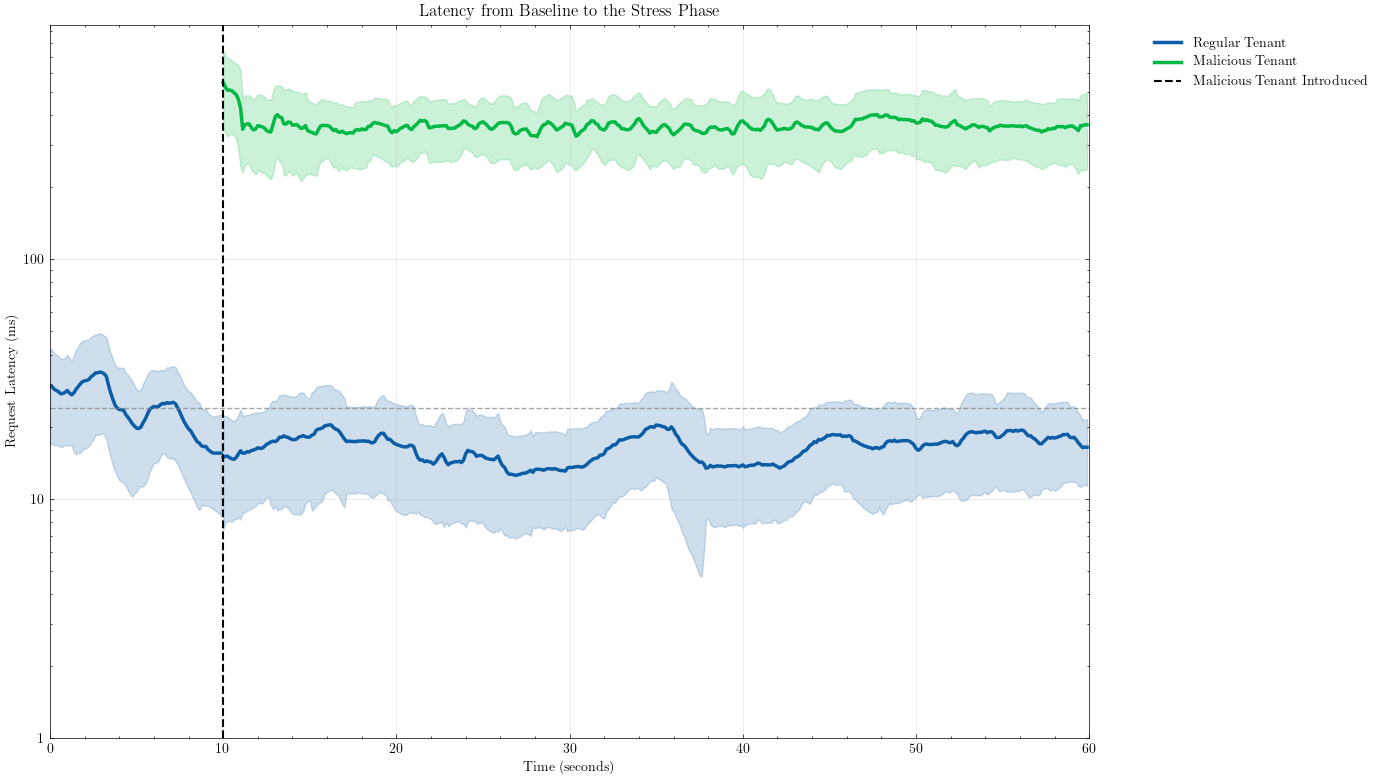


BASELINE TO STRESS TRANSITION ANALYSIS

BASELINE PHASE (0-10s):
  Regular Tenant: 23.2ms avg, 8374 requests
  Malicious Tenant: 541.0ms avg, 1 requests

STRESS TEST PHASE (10s-60s):
  Malicious Tenant: 358.8ms avg (+-33.7%), 84037 requests
  Regular Tenant: 16.0ms avg (+-31.1%), 30007 requests


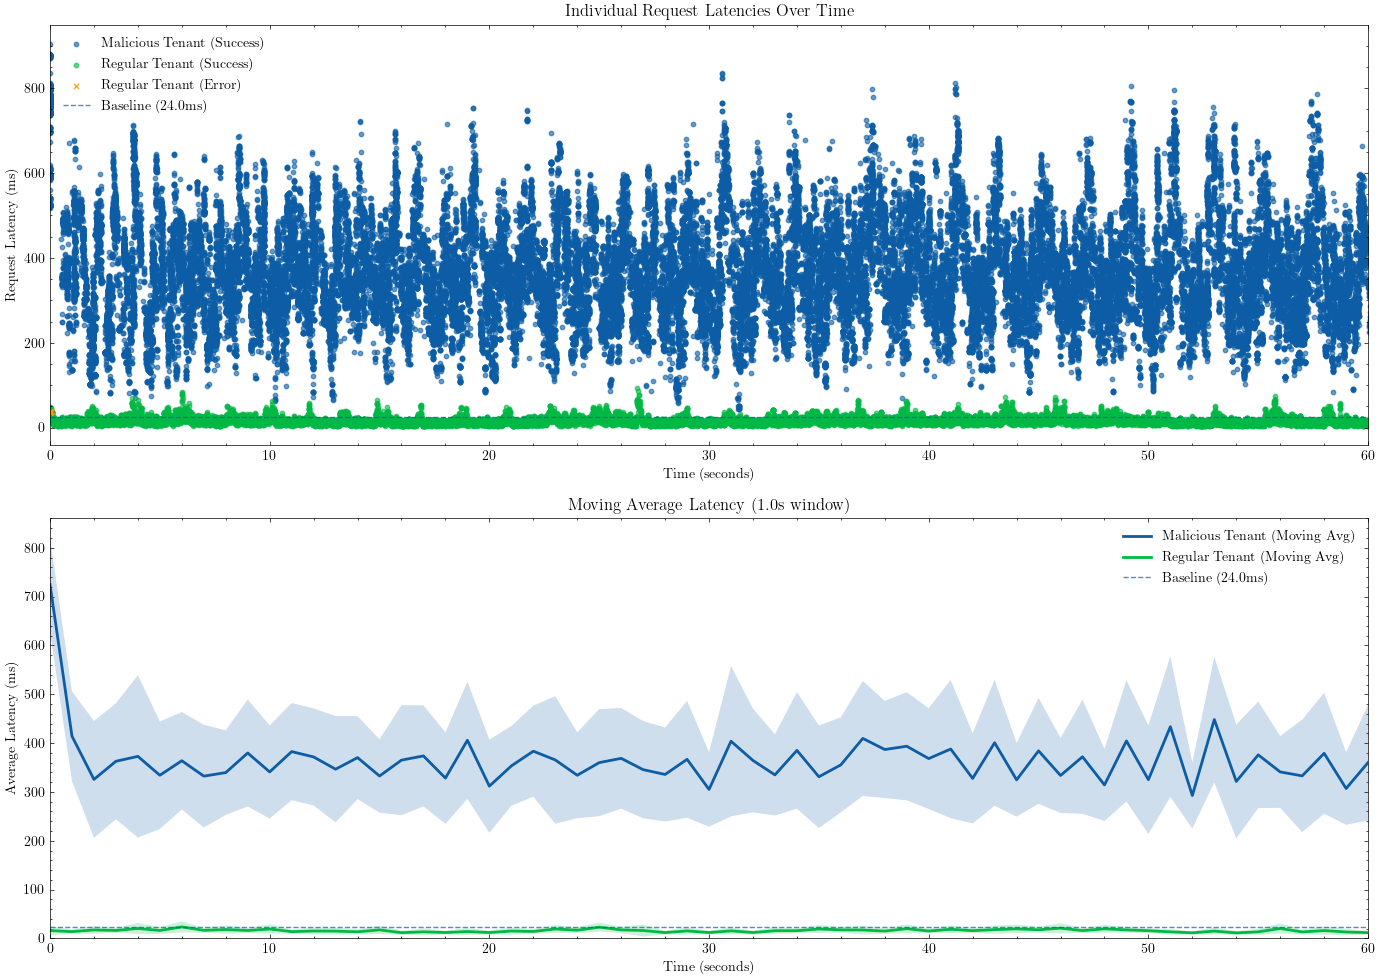

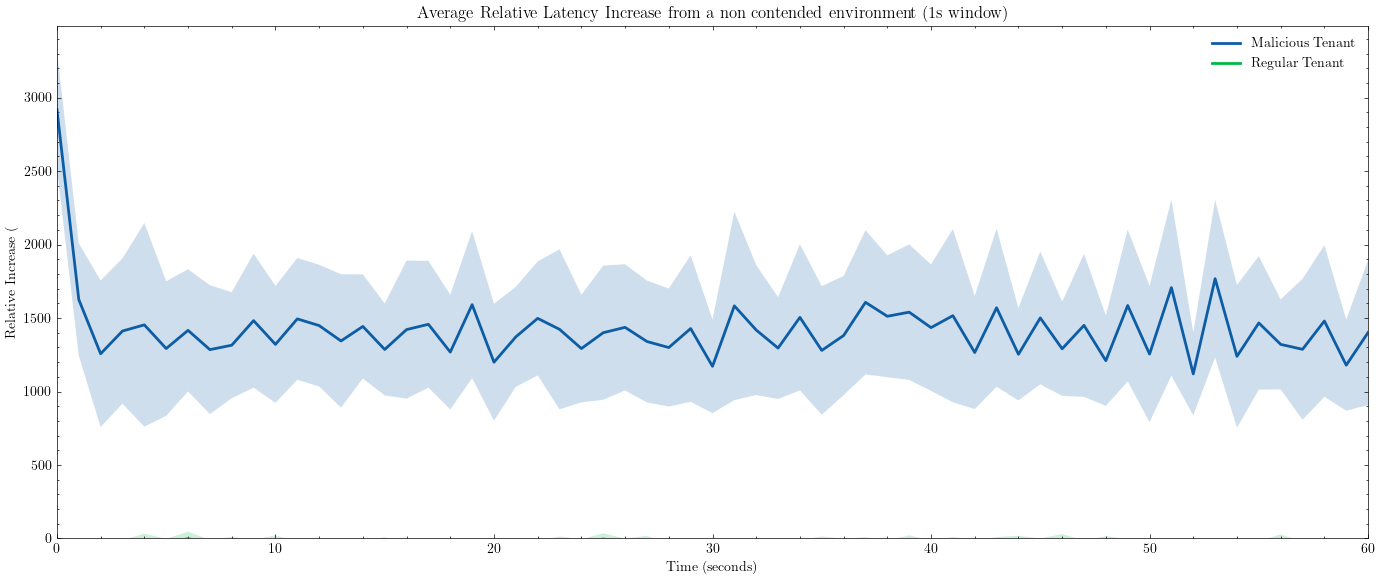

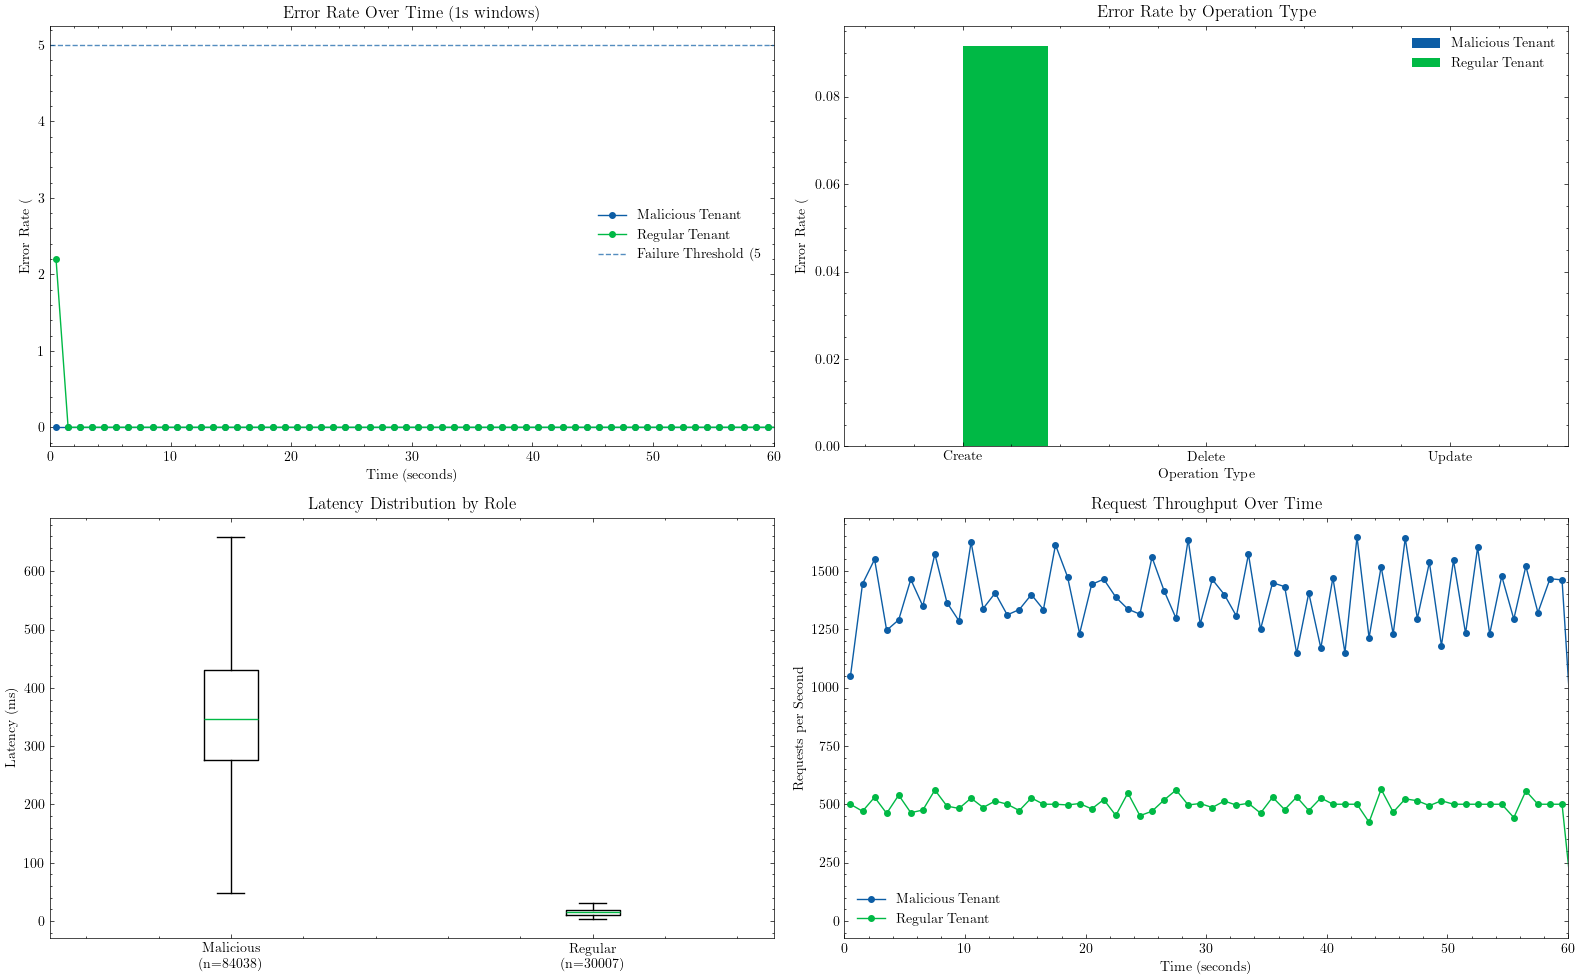

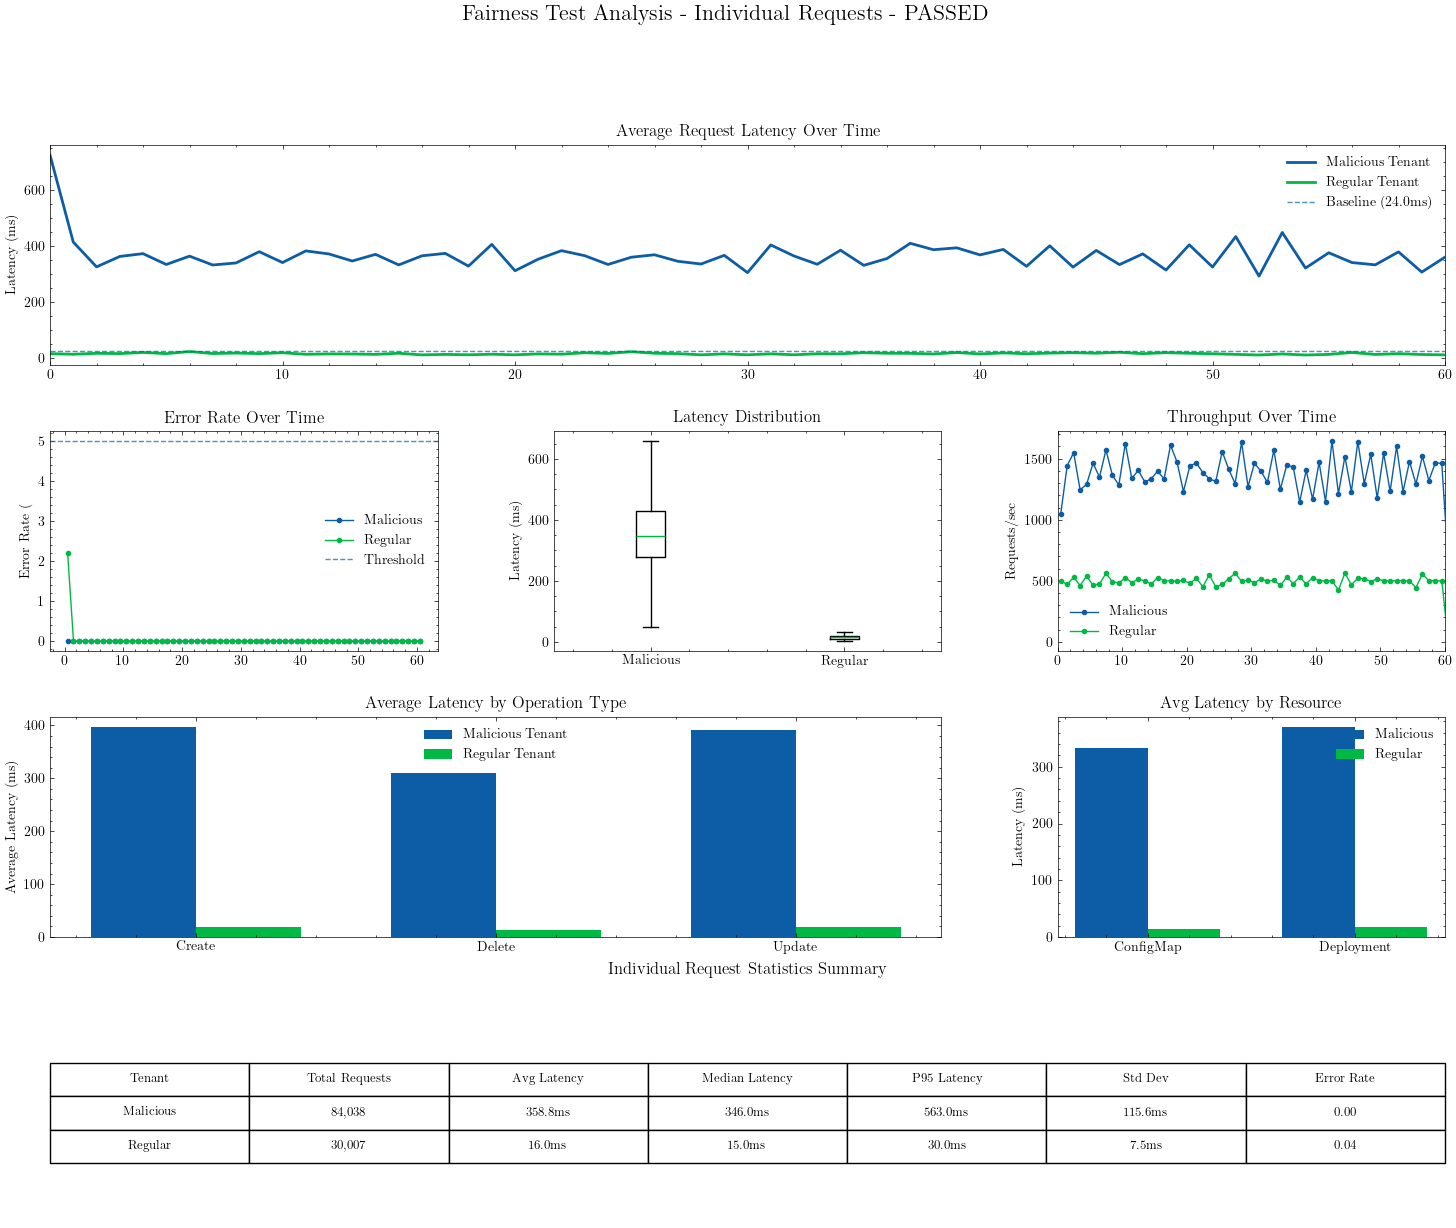


Analysis complete! Plots saved with timestamp: 1750008227_1750008227


(      start_time     role  duration_ms operation    resource  is_error  \
 0       0.002842  Regular           83    Create  Deployment     False   
 1       0.002853  Regular           84    Create  Deployment     False   
 2       0.002864  Regular           82    Create  Deployment     False   
 3       0.002879  Regular           45    Create  Deployment     False   
 4       0.002896  Regular           40    Create  Deployment     False   
 ...          ...      ...          ...       ...         ...       ...   
 8384   10.029082  Regular            8    Delete   ConfigMap     False   
 8385   10.029579  Regular           13    Create   ConfigMap     False   
 8386   10.030377  Regular           13    Update  Deployment     False   
 8387   10.035432  Regular           10    Update  Deployment     False   
 8388   10.045859  Regular            3    Delete   ConfigMap     False   
 
       elapsed_seconds  duration_seconds     phase  
 0            0.000000             0.083  bas

In [ ]:
# Run the analysis
analyze_fairness_test("./60_sec/kubevirt/data", "./60_sec/kubevirt/results")